In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import os

folder_path = 'datasets/retrofit/resampled'

dfs = []

for filename in os.listdir(folder_path):
    if filename.endswith('with_comfort.csv'):
        file_path = os.path.join(folder_path, filename)
        df = pd.read_csv(file_path)
       
        df['timestamp'] = pd.to_datetime(df['timestamps'])
        
        df.drop(columns=['timestamps'], inplace=True)
        df.set_index('timestamp', inplace=True)
        df.sort_index(inplace=True)
        dfs.append(df)




In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class HVACOffDataset(Dataset):
    def __init__(self, df, input_cols, target_col='Tin_target', window_size=6):
        
        self.X_seq = []
        self.y = []
        self.is_test_flags = []

        data = df[input_cols + [target_col, 'is_test']].copy()

        arr = data[input_cols].values
        target = data[target_col].values
        flags = data['is_test'].values

        for i in range(window_size, len(data)):
            self.X_seq.append(arr[i - window_size:i])
            self.y.append(target[i])
            self.is_test_flags.append(flags[i])

        self.X_seq = torch.tensor(self.X_seq, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)
        self.is_test_flags = np.array(self.is_test_flags)

    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X_seq[idx], self.y[idx]

class LSTMWithFuture(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=0.15, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x_seq):
        _, (hn, _) = self.lstm(x_seq)
        return self.fc(hn[-1]).squeeze(-1)

class CNNLSTMWithFuture(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, cnn_out_channels=32, kernel_size=3):
        super().__init__()
        
        self.conv1d = nn.Conv1d(
            in_channels=input_size, 
            out_channels=cnn_out_channels, 
            kernel_size=kernel_size, 
            padding=kernel_size // 2
        )
        self.relu = nn.ReLU()
        
        self.lstm = nn.LSTM(
            input_size=cnn_out_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=0.15,
            batch_first=True
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x_seq):  
        x_seq = x_seq.permute(0, 2, 1) 
        x_seq = self.relu(self.conv1d(x_seq))  
        x_seq = x_seq.permute(0, 2, 1) 
        
        # LSTM + output
        _, (hn, _) = self.lstm(x_seq)
        return self.fc(hn[-1]).squeeze(-1)

======= House 0 =========
NaN rows in inputs/target: 1
Rows before drop: 17659, after drop: 17658
Scaling columns: ['Tin', 'Tout', 'T_diff']


C:\Users\Kelsier\AppData\Local\Temp\ipykernel_7532\2024088952.py:31: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  self.X_seq = torch.tensor(self.X_seq, dtype=torch.float32)


Epoch 1: Loss = 55.2142
✅ Saved best model at epoch 1 → models/df_0\best_tin.pt
Epoch 2: Loss = 2.5401
✅ Saved best model at epoch 2 → models/df_0\best_tin.pt
Epoch 3: Loss = 2.5436
Epoch 4: Loss = 2.5483
Epoch 5: Loss = 2.5266
✅ Saved best model at epoch 5 → models/df_0\best_tin.pt
Epoch 6: Loss = 1.1193
✅ Saved best model at epoch 6 → models/df_0\best_tin.pt
Epoch 7: Loss = 0.2721
✅ Saved best model at epoch 7 → models/df_0\best_tin.pt
Epoch 8: Loss = 0.1191
✅ Saved best model at epoch 8 → models/df_0\best_tin.pt
Epoch 9: Loss = 0.0875
✅ Saved best model at epoch 9 → models/df_0\best_tin.pt
Epoch 10: Loss = 0.0758
✅ Saved best model at epoch 10 → models/df_0\best_tin.pt
Epoch 11: Loss = 0.0691
✅ Saved best model at epoch 11 → models/df_0\best_tin.pt
Epoch 12: Loss = 0.0655
✅ Saved best model at epoch 12 → models/df_0\best_tin.pt
Epoch 13: Loss = 0.0638
✅ Saved best model at epoch 13 → models/df_0\best_tin.pt
Epoch 14: Loss = 0.0615
✅ Saved best model at epoch 14 → models/df_0\best_ti

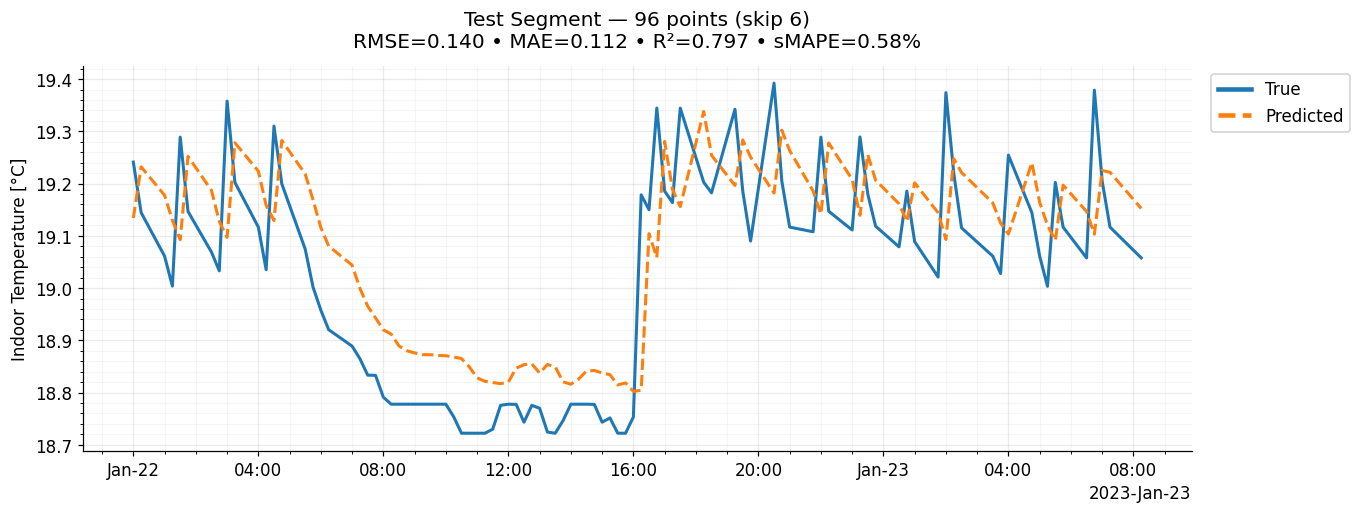

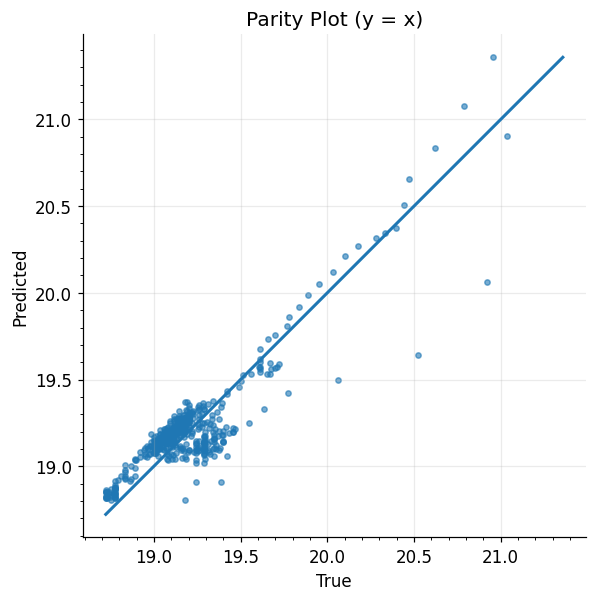

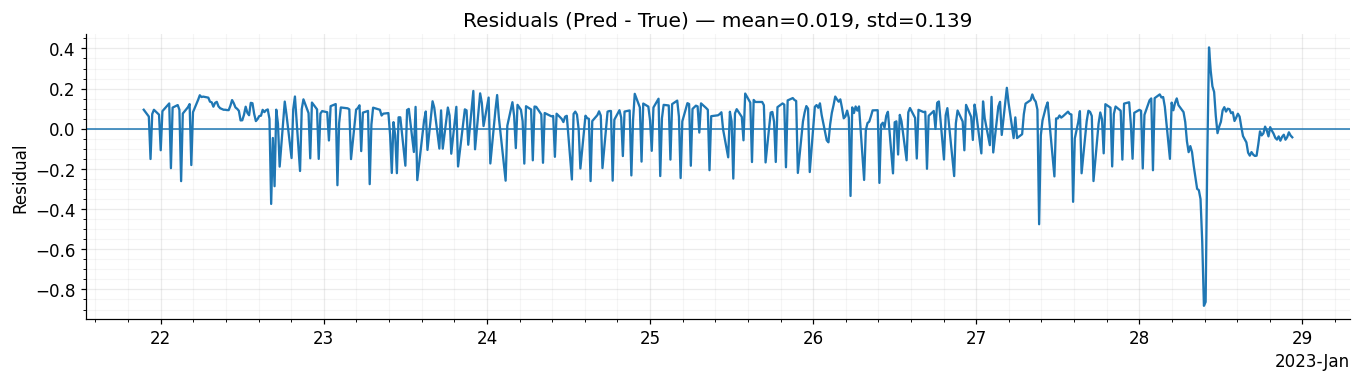

======= House 1 =========
NaN rows in inputs/target: 1
Rows before drop: 5251, after drop: 5250
Scaling columns: ['Tin', 'Tout', 'T_diff']
Epoch 1: Loss = 200.8010
✅ Saved best model at epoch 1 → models/df_1\best_tin.pt
Epoch 2: Loss = 16.7957
✅ Saved best model at epoch 2 → models/df_1\best_tin.pt
Epoch 3: Loss = 4.0012
✅ Saved best model at epoch 3 → models/df_1\best_tin.pt
Epoch 4: Loss = 3.6192
✅ Saved best model at epoch 4 → models/df_1\best_tin.pt
Epoch 5: Loss = 3.6203
Epoch 6: Loss = 3.6175
✅ Saved best model at epoch 6 → models/df_1\best_tin.pt
Epoch 7: Loss = 3.6122
✅ Saved best model at epoch 7 → models/df_1\best_tin.pt
Epoch 8: Loss = 3.6111
✅ Saved best model at epoch 8 → models/df_1\best_tin.pt
Epoch 9: Loss = 3.6115
Epoch 10: Loss = 3.6143
Epoch 11: Loss = 3.6092
✅ Saved best model at epoch 11 → models/df_1\best_tin.pt
Epoch 12: Loss = 3.6051
✅ Saved best model at epoch 12 → models/df_1\best_tin.pt
Epoch 13: Loss = 3.1478
✅ Saved best model at epoch 13 → models/df_1\best

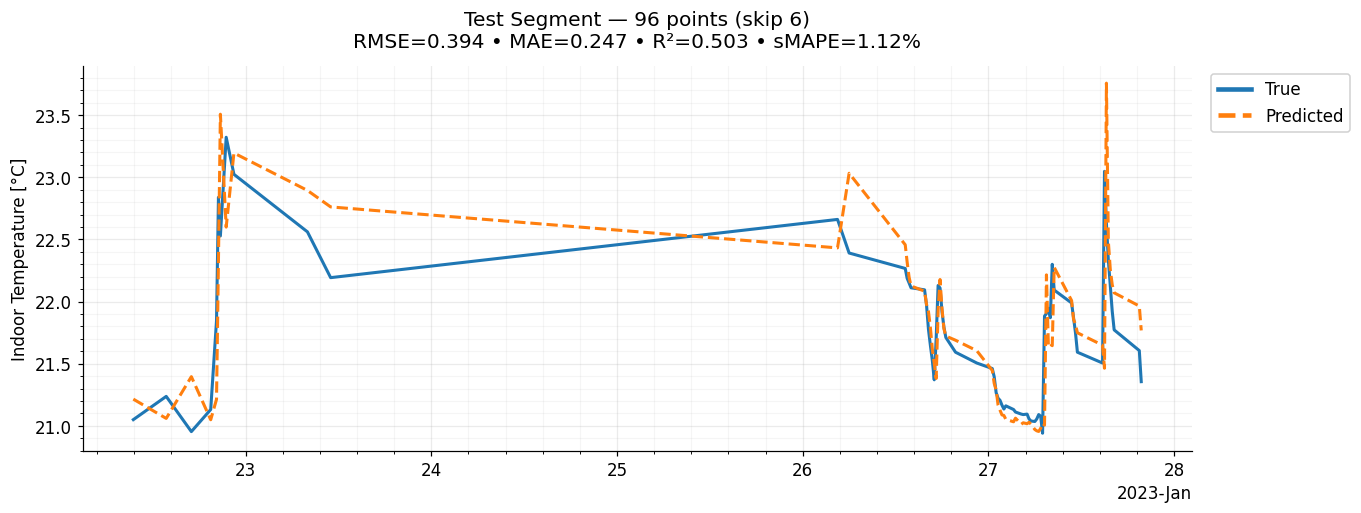

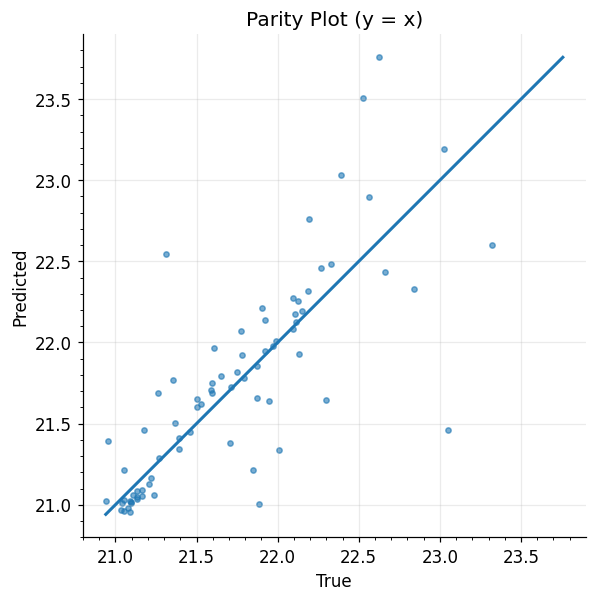

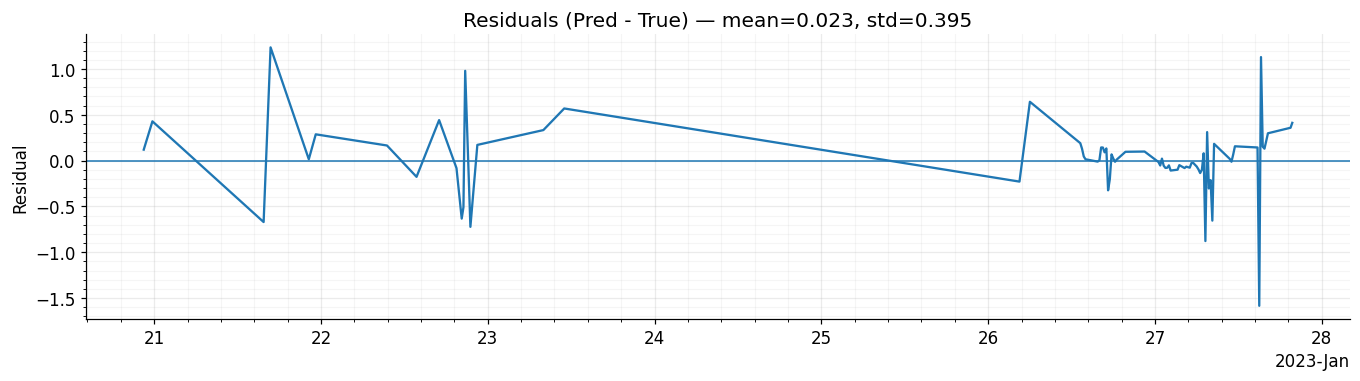

======= House 2 =========
NaN rows in inputs/target: 1
Rows before drop: 12078, after drop: 12077
Scaling columns: ['Tin', 'Tout', 'T_diff']
Epoch 1: Loss = 78.0576
✅ Saved best model at epoch 1 → models/df_2\best_tin.pt
Epoch 2: Loss = 3.5648
✅ Saved best model at epoch 2 → models/df_2\best_tin.pt
Epoch 3: Loss = 3.5559
✅ Saved best model at epoch 3 → models/df_2\best_tin.pt
Epoch 4: Loss = 3.5521
✅ Saved best model at epoch 4 → models/df_2\best_tin.pt
Epoch 5: Loss = 3.4910
✅ Saved best model at epoch 5 → models/df_2\best_tin.pt
Epoch 6: Loss = 1.3738
✅ Saved best model at epoch 6 → models/df_2\best_tin.pt
Epoch 7: Loss = 0.4551
✅ Saved best model at epoch 7 → models/df_2\best_tin.pt
Epoch 8: Loss = 0.2441
✅ Saved best model at epoch 8 → models/df_2\best_tin.pt
Epoch 9: Loss = 0.1687
✅ Saved best model at epoch 9 → models/df_2\best_tin.pt
Epoch 10: Loss = 0.1386
✅ Saved best model at epoch 10 → models/df_2\best_tin.pt
Epoch 11: Loss = 0.1230
✅ Saved best model at epoch 11 → models/df

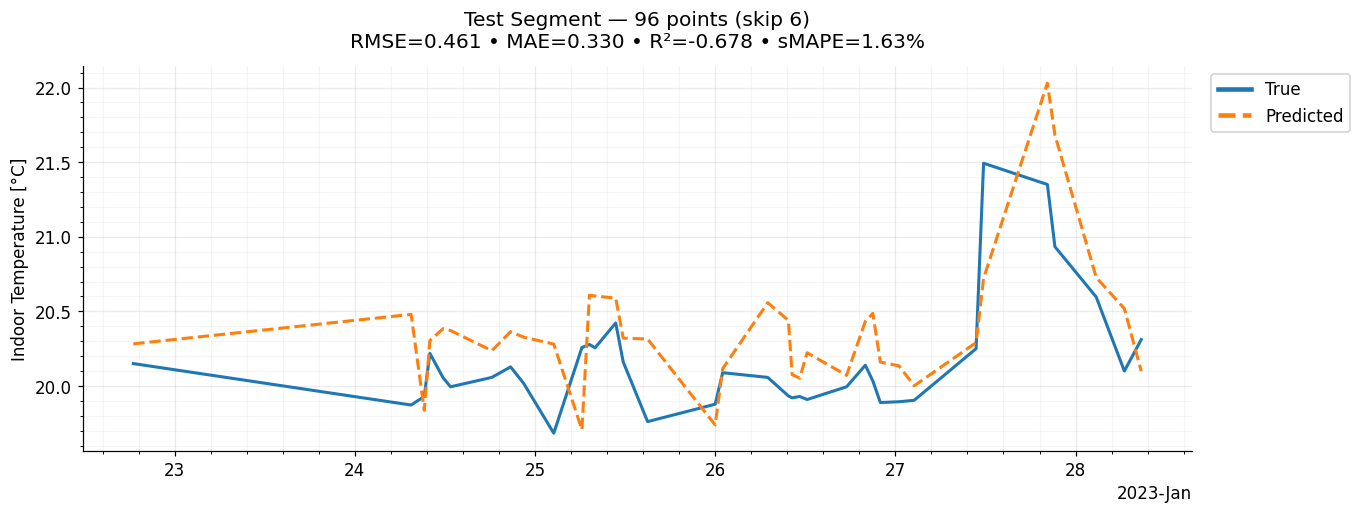

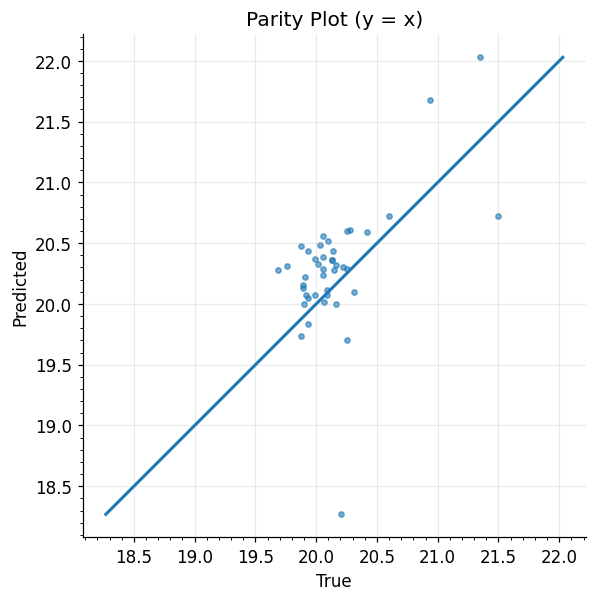

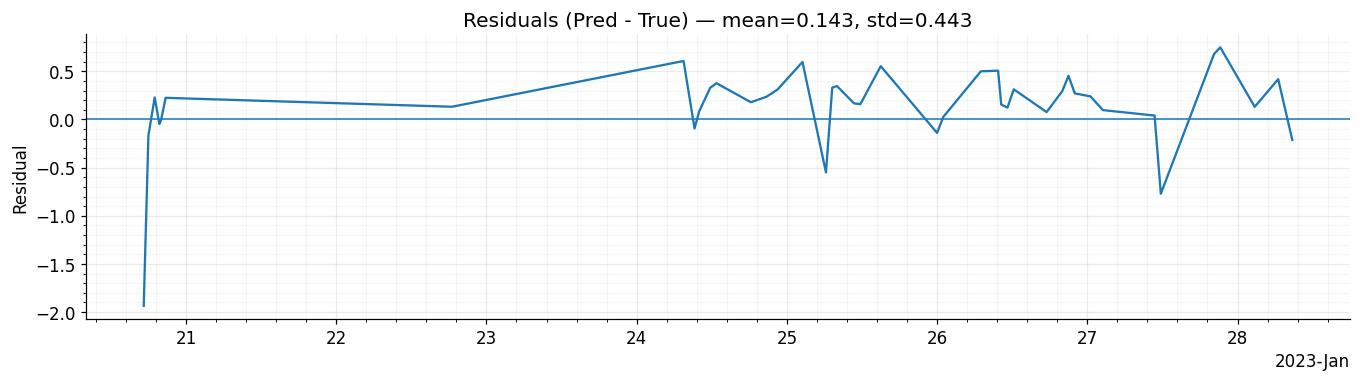

======= House 3 =========
NaN rows in inputs/target: 1
Rows before drop: 8940, after drop: 8939
Scaling columns: ['Tin', 'Tout', 'T_diff']
Epoch 1: Loss = 132.0207
✅ Saved best model at epoch 1 → models/df_3\best_tin.pt
Epoch 2: Loss = 2.5603
✅ Saved best model at epoch 2 → models/df_3\best_tin.pt
Epoch 3: Loss = 1.6236
✅ Saved best model at epoch 3 → models/df_3\best_tin.pt
Epoch 4: Loss = 1.6265
Epoch 5: Loss = 1.6272
Epoch 6: Loss = 1.6230
✅ Saved best model at epoch 6 → models/df_3\best_tin.pt
Epoch 7: Loss = 1.6264
Epoch 8: Loss = 1.6219
✅ Saved best model at epoch 8 → models/df_3\best_tin.pt
Epoch 9: Loss = 1.5684
✅ Saved best model at epoch 9 → models/df_3\best_tin.pt
Epoch 10: Loss = 1.1925
✅ Saved best model at epoch 10 → models/df_3\best_tin.pt
Epoch 11: Loss = 0.5738
✅ Saved best model at epoch 11 → models/df_3\best_tin.pt
Epoch 12: Loss = 0.3159
✅ Saved best model at epoch 12 → models/df_3\best_tin.pt
Epoch 13: Loss = 0.2146
✅ Saved best model at epoch 13 → models/df_3\best

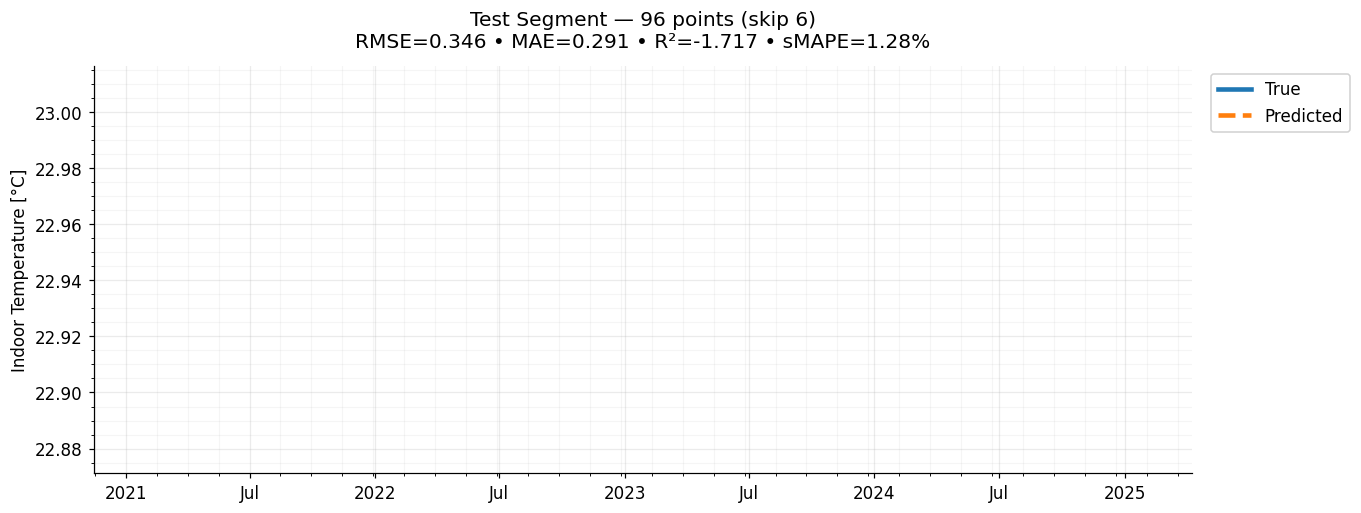

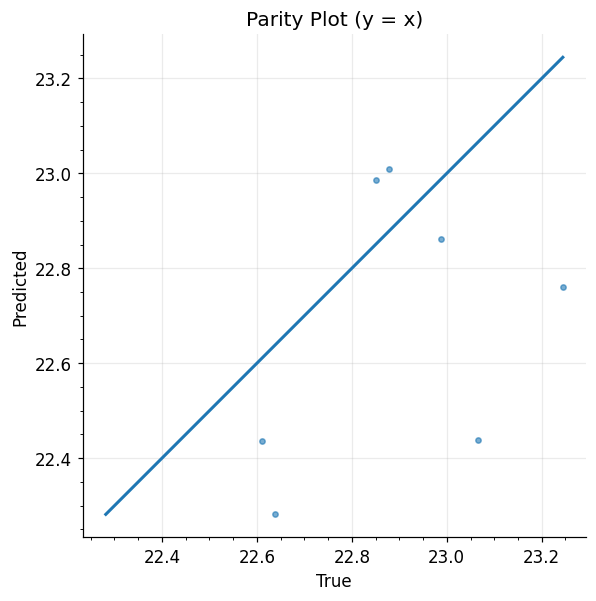

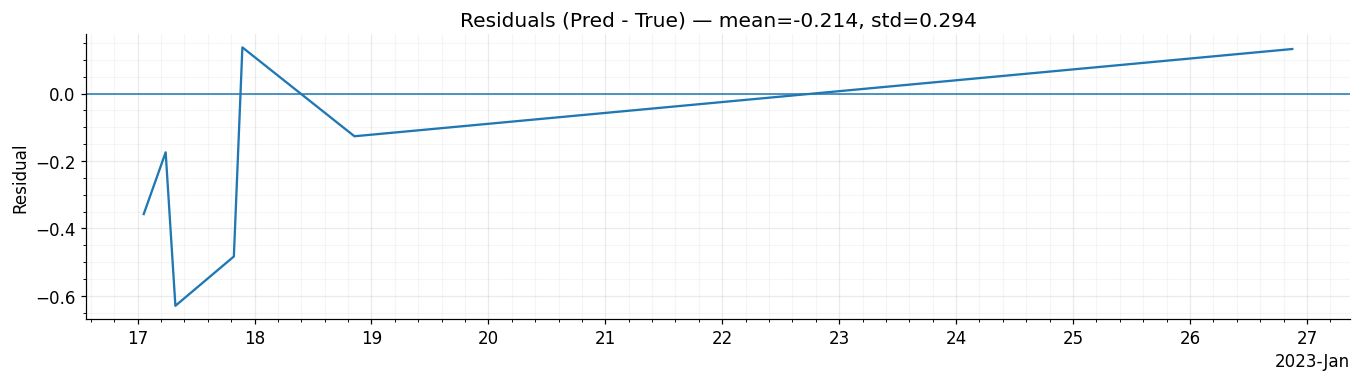

======= House 4 =========
NaN rows in inputs/target: 1
Rows before drop: 21289, after drop: 21288
Scaling columns: ['Tin', 'Tout', 'T_diff']
Epoch 1: Loss = 55.4972
✅ Saved best model at epoch 1 → models/df_4\best_tin.pt
Epoch 2: Loss = 2.3689
✅ Saved best model at epoch 2 → models/df_4\best_tin.pt
Epoch 3: Loss = 2.2332
✅ Saved best model at epoch 3 → models/df_4\best_tin.pt
Epoch 4: Loss = 1.2064
✅ Saved best model at epoch 4 → models/df_4\best_tin.pt
Epoch 5: Loss = 0.2921
✅ Saved best model at epoch 5 → models/df_4\best_tin.pt
Epoch 6: Loss = 0.1300
✅ Saved best model at epoch 6 → models/df_4\best_tin.pt
Epoch 7: Loss = 0.0926
✅ Saved best model at epoch 7 → models/df_4\best_tin.pt
Epoch 8: Loss = 0.0763
✅ Saved best model at epoch 8 → models/df_4\best_tin.pt
Epoch 9: Loss = 0.0664
✅ Saved best model at epoch 9 → models/df_4\best_tin.pt
Epoch 10: Loss = 0.0612
✅ Saved best model at epoch 10 → models/df_4\best_tin.pt
Epoch 11: Loss = 0.0579
✅ Saved best model at epoch 11 → models/df

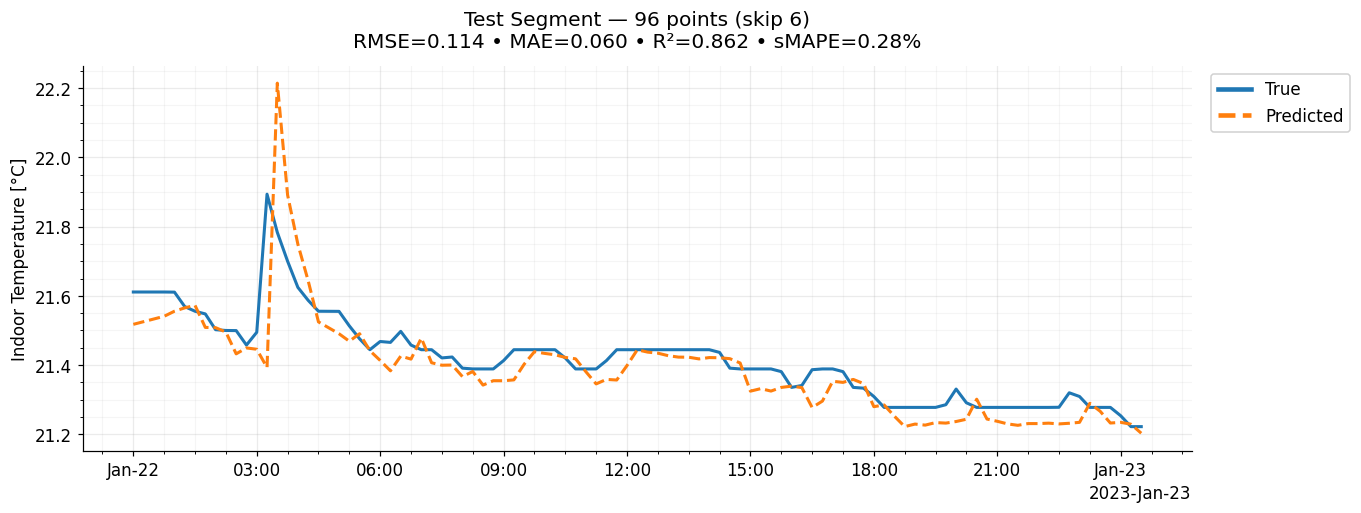

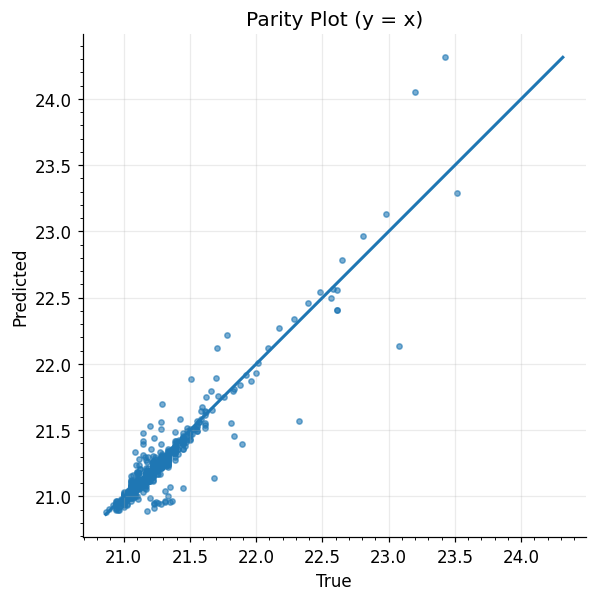

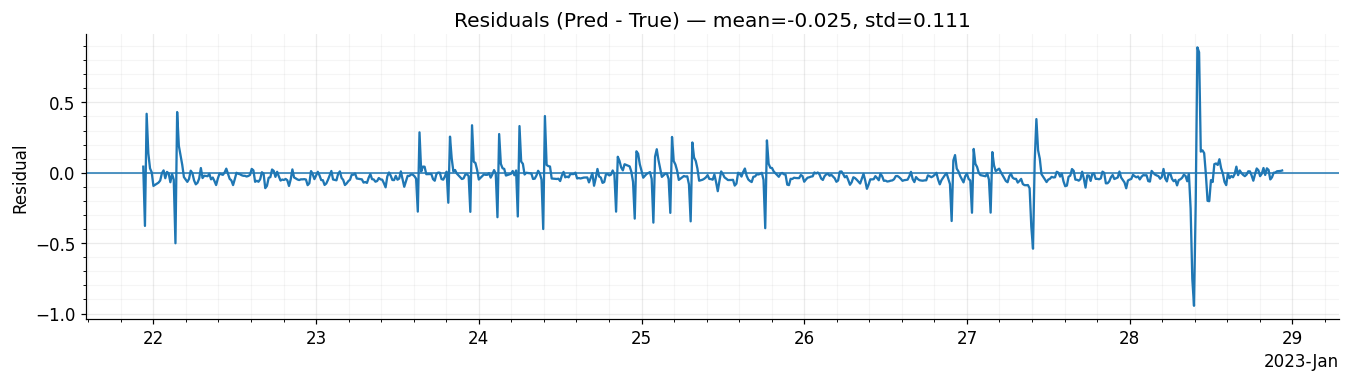

======= House 5 =========
NaN rows in inputs/target: 1
Rows before drop: 14811, after drop: 14810
Scaling columns: ['Tin', 'Tout', 'T_diff']
Epoch 1: Loss = 68.6494
✅ Saved best model at epoch 1 → models/df_5\best_tin.pt
Epoch 2: Loss = 2.6514
✅ Saved best model at epoch 2 → models/df_5\best_tin.pt
Epoch 3: Loss = 2.6482
✅ Saved best model at epoch 3 → models/df_5\best_tin.pt
Epoch 4: Loss = 2.6138
✅ Saved best model at epoch 4 → models/df_5\best_tin.pt
Epoch 5: Loss = 1.8015
✅ Saved best model at epoch 5 → models/df_5\best_tin.pt
Epoch 6: Loss = 0.5562
✅ Saved best model at epoch 6 → models/df_5\best_tin.pt
Epoch 7: Loss = 0.2631
✅ Saved best model at epoch 7 → models/df_5\best_tin.pt
Epoch 8: Loss = 0.1688
✅ Saved best model at epoch 8 → models/df_5\best_tin.pt
Epoch 9: Loss = 0.1315
✅ Saved best model at epoch 9 → models/df_5\best_tin.pt
Epoch 10: Loss = 0.1111
✅ Saved best model at epoch 10 → models/df_5\best_tin.pt
Epoch 11: Loss = 0.0968
✅ Saved best model at epoch 11 → models/df

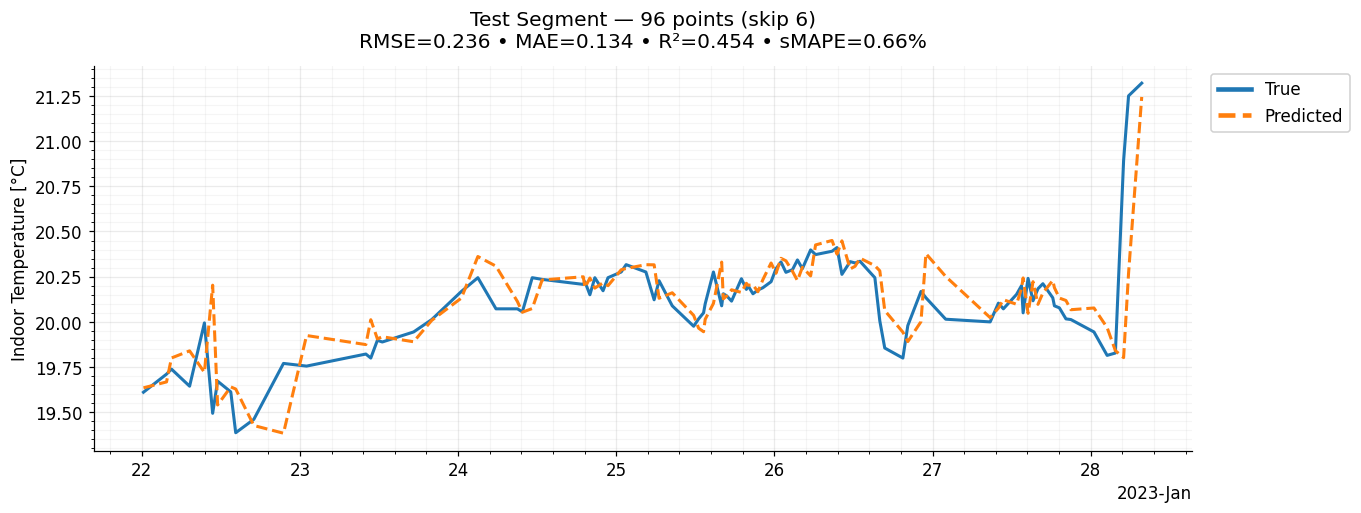

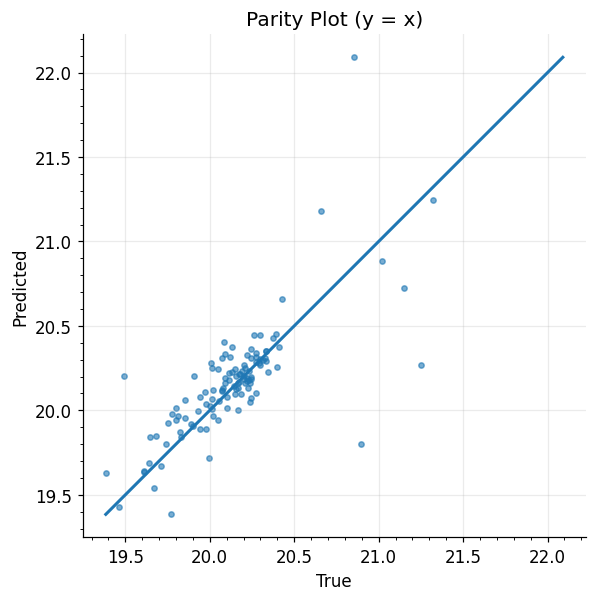

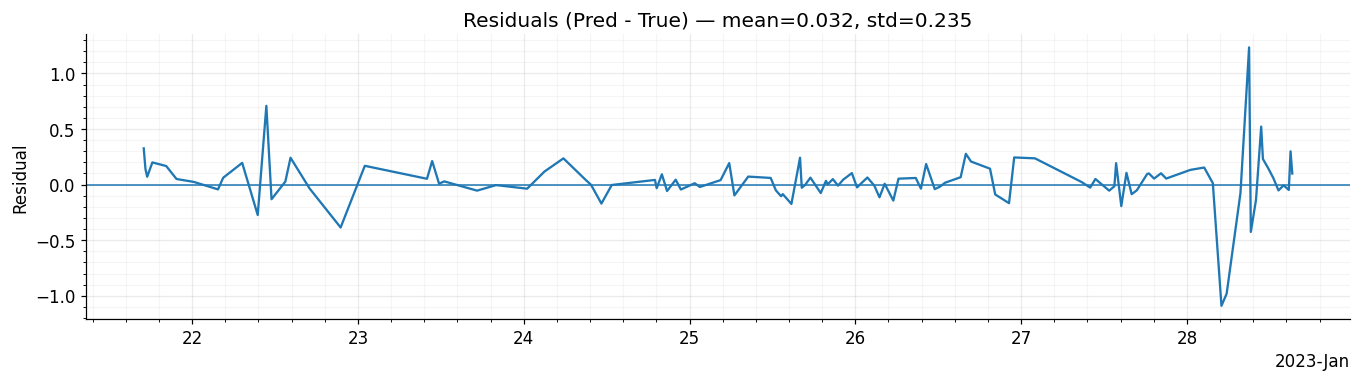

======= House 6 =========
NaN rows in inputs/target: 1
Rows before drop: 10908, after drop: 10907
Scaling columns: ['Tin', 'Tout', 'T_diff']
Epoch 1: Loss = 73.6283
✅ Saved best model at epoch 1 → models/df_6\best_tin.pt
Epoch 2: Loss = 4.2614
✅ Saved best model at epoch 2 → models/df_6\best_tin.pt
Epoch 3: Loss = 4.2535
✅ Saved best model at epoch 3 → models/df_6\best_tin.pt
Epoch 4: Loss = 4.2503
✅ Saved best model at epoch 4 → models/df_6\best_tin.pt
Epoch 5: Loss = 4.1906
✅ Saved best model at epoch 5 → models/df_6\best_tin.pt
Epoch 6: Loss = 1.6800
✅ Saved best model at epoch 6 → models/df_6\best_tin.pt
Epoch 7: Loss = 0.4582
✅ Saved best model at epoch 7 → models/df_6\best_tin.pt
Epoch 8: Loss = 0.3062
✅ Saved best model at epoch 8 → models/df_6\best_tin.pt
Epoch 9: Loss = 0.2154
✅ Saved best model at epoch 9 → models/df_6\best_tin.pt
Epoch 10: Loss = 0.1773
✅ Saved best model at epoch 10 → models/df_6\best_tin.pt
Epoch 11: Loss = 0.1451
✅ Saved best model at epoch 11 → models/df

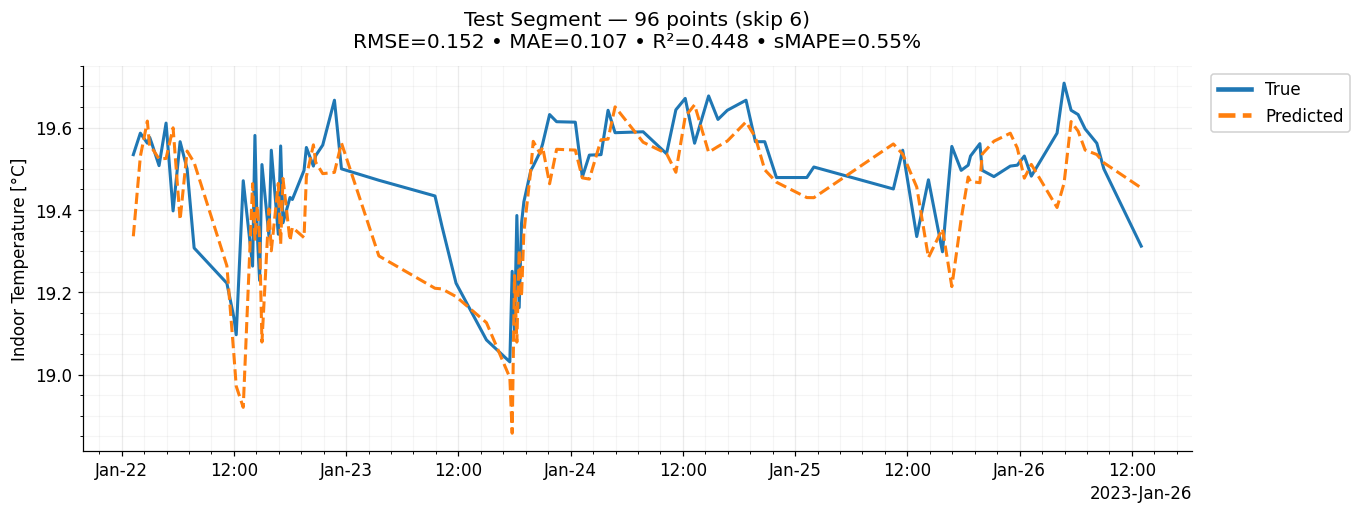

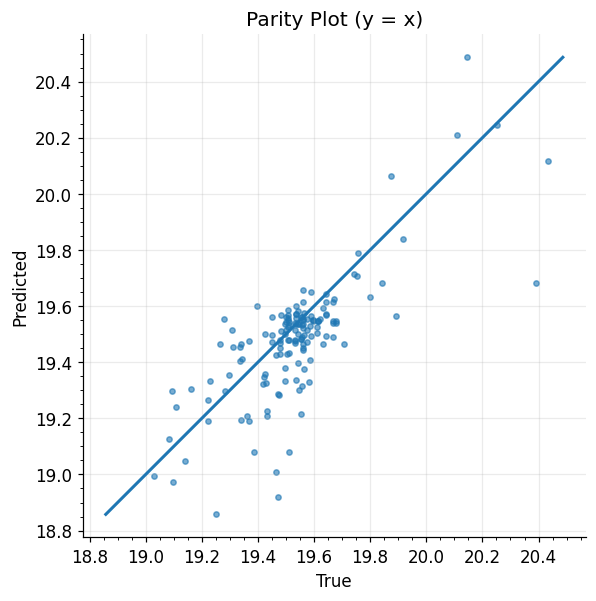

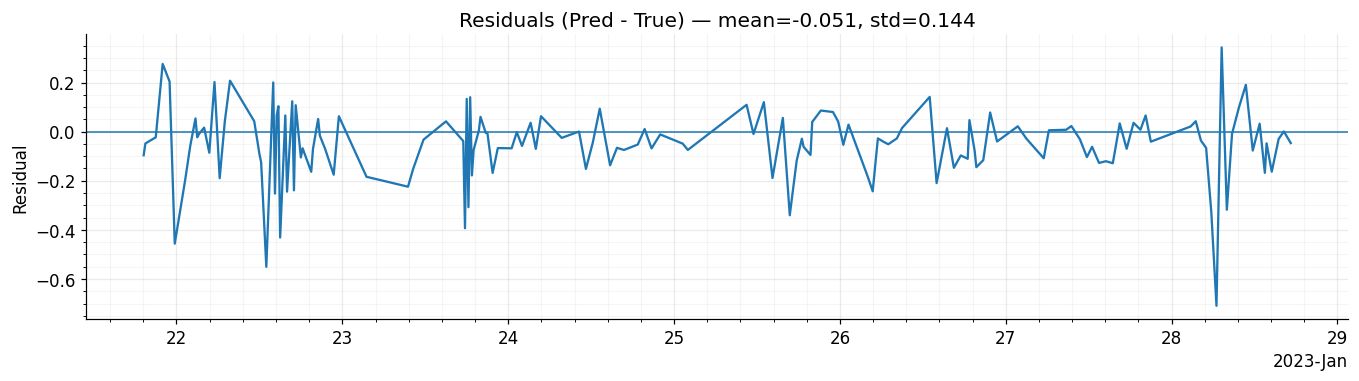

======= House 7 =========
NaN rows in inputs/target: 1
Rows before drop: 7696, after drop: 7695
Scaling columns: ['Tin', 'Tout', 'T_diff']
Epoch 1: Loss = 97.7118
✅ Saved best model at epoch 1 → models/df_7\best_tin.pt
Epoch 2: Loss = 3.4417
✅ Saved best model at epoch 2 → models/df_7\best_tin.pt
Epoch 3: Loss = 3.1750
✅ Saved best model at epoch 3 → models/df_7\best_tin.pt
Epoch 4: Loss = 3.1553
✅ Saved best model at epoch 4 → models/df_7\best_tin.pt
Epoch 5: Loss = 3.1545
✅ Saved best model at epoch 5 → models/df_7\best_tin.pt
Epoch 6: Loss = 3.1455
✅ Saved best model at epoch 6 → models/df_7\best_tin.pt
Epoch 7: Loss = 3.1420
✅ Saved best model at epoch 7 → models/df_7\best_tin.pt
Epoch 8: Loss = 3.1490
Epoch 9: Loss = 2.6226
✅ Saved best model at epoch 9 → models/df_7\best_tin.pt
Epoch 10: Loss = 0.9824
✅ Saved best model at epoch 10 → models/df_7\best_tin.pt
Epoch 11: Loss = 0.5985
✅ Saved best model at epoch 11 → models/df_7\best_tin.pt
Epoch 12: Loss = 0.4125
✅ Saved best model 

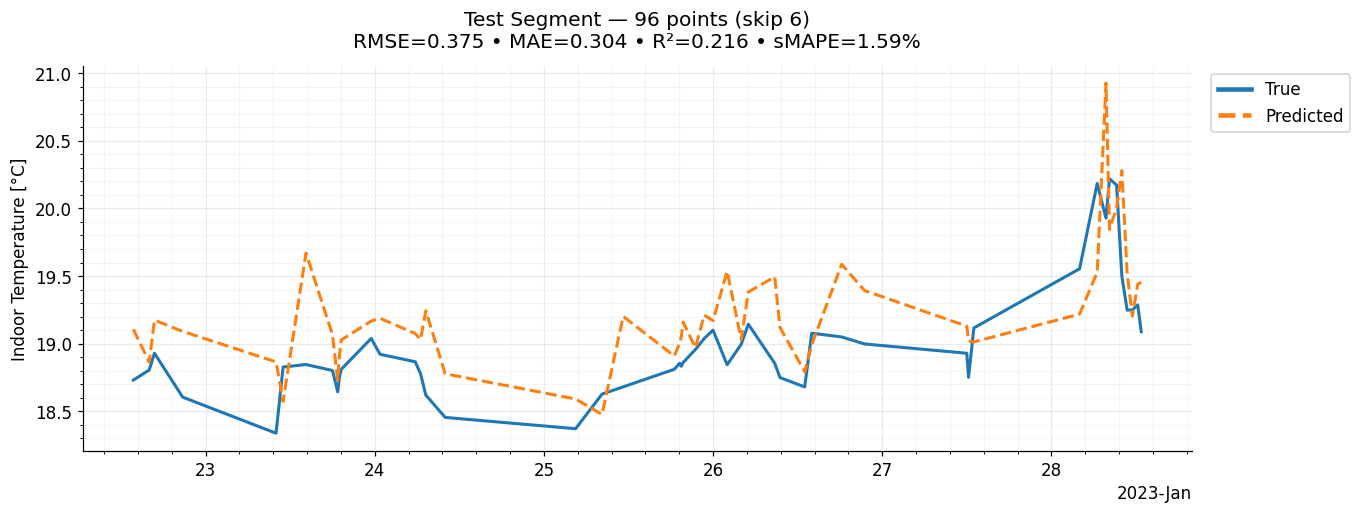

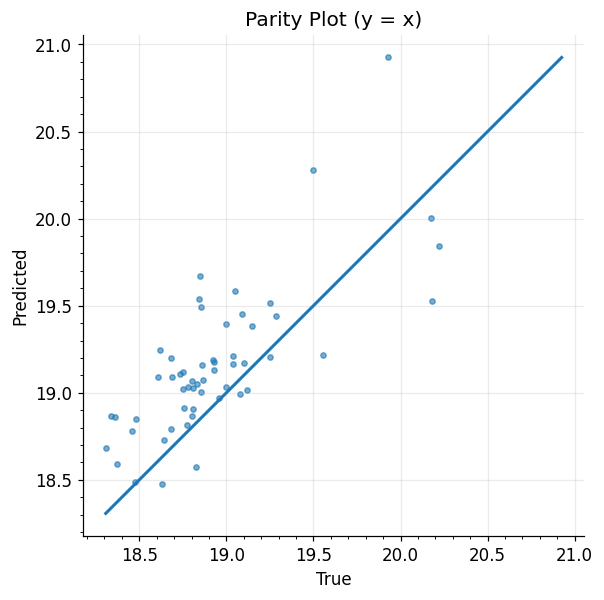

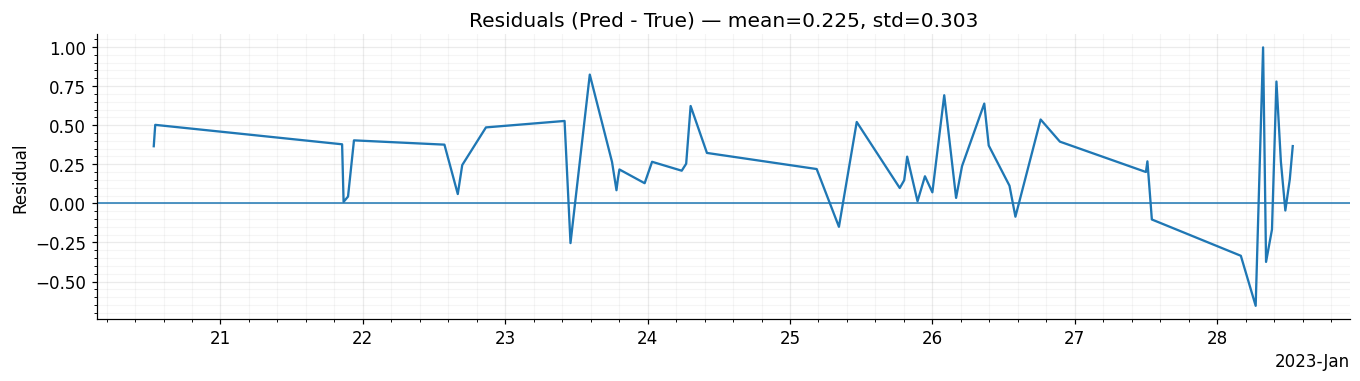

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
    
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0

def _time_axis(ax):
    loc = AutoDateLocator()
    fmt = ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    ax.grid(True, which="major")
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)
    
def train_lstm_model(df, input_cols, target_col='Tin_target', window_size=6, batch_size=64, use_scaler=True, epochs=20, hidden_size=128, num_layers=3, lr=0.001, save_dir=None):
    scaler = None
    df_proc = df.copy()
    os.makedirs(save_dir, exist_ok=True)

    if use_scaler:
        scaler = StandardScaler()
        scaling_cols = [col for col in input_cols if not (col.startswith('hvac_') or col.startswith('hour_'))]
        print(f"Scaling columns: {scaling_cols}")
        scaler.fit(df_proc[df_proc['is_test'] == False][scaling_cols])
        df_proc[scaling_cols] = scaler.transform(df_proc[scaling_cols])
        
    dataset = HVACOffDataset(df_proc, input_cols, target_col, window_size)
  
    test_idx = np.where(dataset.is_test_flags == True)[0]
    train_idx = np.where(dataset.is_test_flags == False)[0]
    
    train_ds = torch.utils.data.Subset(dataset, train_idx)
    test_ds = torch.utils.data.Subset(dataset, test_idx)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # model = LSTMWithFuture(input_size=len(input_cols), hidden_size=hidden_size, num_layers=num_layers) if target_col == 'Tin_target' else CNNLSTMWithFuture(input_size=len(input_cols), hidden_size=hidden_size, num_layers=num_layers, cnn_out_channels=32, kernel_size=3)
    if target_col == 'Tin_target':
        model = LSTMWithFuture(input_size=len(input_cols), hidden_size=hidden_size, num_layers=num_layers)
        ckpt_name = "best_tin.pt"       
    else:
        model = CNNLSTMWithFuture(input_size=len(input_cols), hidden_size=hidden_size, num_layers=num_layers,
                                  cnn_out_channels=32, kernel_size=3)
        ckpt_name = f"best_rh.pt"   

    ckpt_path = os.path.join(save_dir, ckpt_name)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best_train_loss = float('inf')
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for xb_seq, yb in train_dl:
            optimizer.zero_grad()
            pred = model(xb_seq)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_dl)
        print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

        if avg_loss < best_train_loss:
            best_train_loss = avg_loss
            torch.save(model.state_dict(), ckpt_path)
            print(f"✅ Saved best model at epoch {epoch+1} → {ckpt_path}")

    model.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
    
    model.eval()

    test_timestamps = [df_proc.iloc[i].name for i in test_idx]

    preds, actuals, times = [], [], []

    with torch.no_grad():
        batch_start = 0
        for xb_seq, yb in test_dl:
            out = model(xb_seq)
            preds.extend(out.numpy())
            actuals.extend(yb.numpy())

            batch_size = len(xb_seq)
            times.extend(test_timestamps[batch_start:batch_start + batch_size])
            batch_start += batch_size

    rmse = root_mean_squared_error(actuals, preds)
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    smp = smape(actuals, preds)
    
    metrics_df = pd.DataFrame(
        {
            "Metric": ["RMSE", "MAE", "R²", "sMAPE (%)"],
            "Value":  [rmse,  mae,   r2,   smp]
        }
    )
    metrics_df["Value"] = metrics_df["Value"].map(lambda v: f"{v:,.4f}")
    print("\n" + "="*47)
    print(" Performance Metrics".center(47, " "))
    print("="*47)
    print(metrics_df.to_string(index=False))
    print("="*47 + "\n")

    target_col_true = target_col + '_true'
    target_col_pred = target_col + '_pred'      
    results = pd.DataFrame(
        {target_col_true: actuals, target_col_pred: preds},
        index=pd.to_datetime(times)
    ).sort_index()
    plt.rcParams.update({
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "font.size": 11,
    })

    ylabel = "Indoor Temperature [°C]" if target_col == "Tin_target" else "RH (%)"


    N_skip = 6
    N_plot = 96
    plot_results = results.iloc[N_skip:N_skip + N_plot]

    fig, ax = plt.subplots(figsize=(12.5, 4.8))
    ax.plot(plot_results.index, plot_results[target_col_true], linewidth=2.0, label="True")
    ax.plot(plot_results.index, plot_results[target_col_pred], linewidth=2.0, linestyle="--", label="Predicted")

    # annotate metrics in subtitle
    ax.set_title(
        f"Test Segment — {N_plot} points (skip {N_skip})\n"
        f"RMSE={rmse:.3f} • MAE={mae:.3f} • R²={r2:.3f} • sMAPE={smp:.2f}%",
        pad=12
    )
    ax.set_ylabel(ylabel)
    _time_axis(ax)

    # move legend outside for clarity
    leg = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    for line in leg.get_lines():
        line.set_linewidth(3)

    fig.tight_layout()
    plt.show()

    # -------------------------------
    # (2) Parity Plot (Prediction vs Truth)
    # -------------------------------
    fig, ax = plt.subplots(figsize=(5.6, 5.6))
    ax.scatter(results[target_col_true], results[target_col_pred], s=12, alpha=0.6)
    mn = np.nanmin([results[target_col_true].min(), results[target_col_pred].min()])
    mx = np.nanmax([results[target_col_true].max(), results[target_col_pred].max()])
    ax.plot([mn, mx], [mn, mx], linestyle="-", linewidth=2.0)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title("Parity Plot (y = x)")
    ax.set_aspect("equal", adjustable="box")
    ax.minorticks_on()
    fig.tight_layout()
    plt.show()

    # -------------------------------
    # (3) Residuals vs Time
    # -------------------------------
    residuals = results[target_col_pred] - results[target_col_true]
    fig, ax = plt.subplots(figsize=(12.5, 3.6))
    ax.plot(results.index, residuals, linewidth=1.5)
    ax.axhline(0.0, linewidth=1.0)
    ax.set_title(
        f"Residuals (Pred - True) — mean={residuals.mean():.3f}, std={residuals.std():.3f}"
    )
    ax.set_ylabel("Residual")
    _time_axis(ax)
    fig.tight_layout()
    plt.show()
    return model, scaler, dataset

input_cols = ['Tin', 'Tout', 'T_diff']

target_col = 'Tin_target'

for index,df in enumerate(dfs):
    print(f"======= House {index} =========")
    df.drop(index=df[df['total_energy'] == 0.0].index, inplace=True)
    lags_out = [1, 2, 3, 4, 96]
    for lag in lags_out:
        df[f'Tout_lag{lag}'] = df['Tout'].shift(lag)

    future_steps = 4
    for i in range(1, future_steps + 1):
        df[f'Tout_fut{i}'] = df['Tout'].shift(-i)

    df['T_diff'] = (df['Tout'] - df['Tin']).bfill()
  

    df['Tin_target']  = df['Tin'].shift(-1).dropna()          
    # df['is_test'] = (df.index >= test_start) & (df.index <= test_end)


    df_off = df[df.hvac_mode == 0].copy()
    original_rows = len(df_off)

    required_cols = input_cols + [target_col]

    nan_mask = df_off[required_cols].isnull().any(axis=1)
    num_nans = nan_mask.sum()
    df_clean = df_off[~nan_mask].copy()
    print(f"NaN rows in inputs/target: {num_nans}")
    print(f"Rows before drop: {original_rows}, after drop: {original_rows - num_nans}")
    # scaler = StandardScaler()
    # scaler.fit(df_clean[df_clean['is_test'] == False][input_cols])

    # df_scaled = df_clean.copy()
    # df_scaled[input_cols] = scaler.transform(df_scaled[input_cols])
    save_dir = f"models/df_{index}"
    save_scaler_dir =  f"models/scalers/df_{index}"
    os.makedirs(save_scaler_dir, exist_ok=True)
    scaler_path = os.path.join(save_scaler_dir, 'scaler_tin.pk1')

    model_tin, scaler_tin, dataset = train_lstm_model(df_clean, input_cols, target_col='Tin_target', window_size=6, batch_size=64, use_scaler=True, epochs=50, hidden_size=128, num_layers=2, lr=0.001, save_dir=save_dir)
    
    joblib.dump(scaler_tin, scaler_path)


======= House 0 =========
Scaling columns: ['RH', 'Tout']
Epoch 1: Loss = 529.2472
✅ Saved best model at epoch 1 → models/df_0\best_rh.pt
Epoch 2: Loss = 200.9772
✅ Saved best model at epoch 2 → models/df_0\best_rh.pt
Epoch 3: Loss = 199.6099
✅ Saved best model at epoch 3 → models/df_0\best_rh.pt
Epoch 4: Loss = 199.6415
Epoch 5: Loss = 184.7295
✅ Saved best model at epoch 5 → models/df_0\best_rh.pt
Epoch 6: Loss = 24.2487
✅ Saved best model at epoch 6 → models/df_0\best_rh.pt
Epoch 7: Loss = 5.5481
✅ Saved best model at epoch 7 → models/df_0\best_rh.pt
Epoch 8: Loss = 3.1331
✅ Saved best model at epoch 8 → models/df_0\best_rh.pt
Epoch 9: Loss = 2.3939
✅ Saved best model at epoch 9 → models/df_0\best_rh.pt
Epoch 10: Loss = 2.0004
✅ Saved best model at epoch 10 → models/df_0\best_rh.pt
Epoch 11: Loss = 1.8376
✅ Saved best model at epoch 11 → models/df_0\best_rh.pt
Epoch 12: Loss = 1.6876
✅ Saved best model at epoch 12 → models/df_0\best_rh.pt
Epoch 13: Loss = 1.6392
✅ Saved best model a

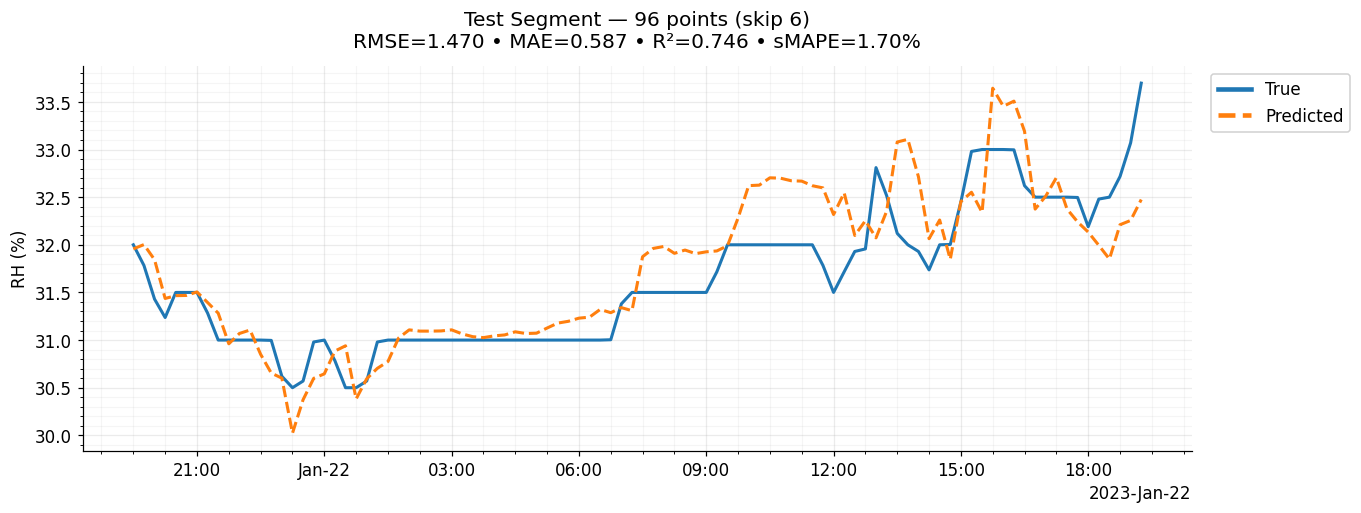

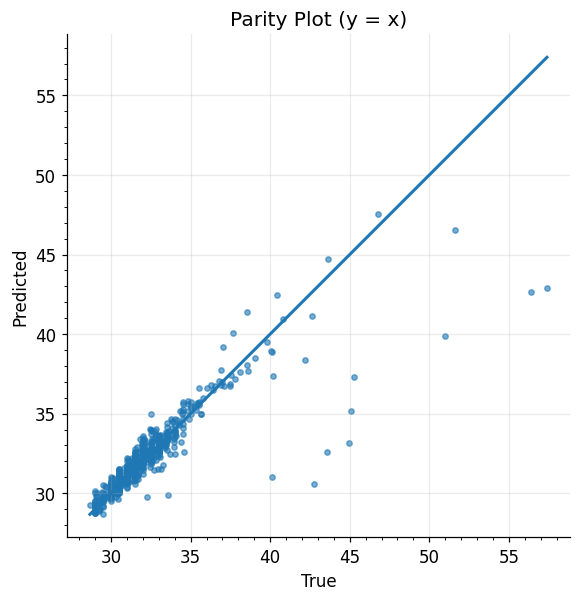

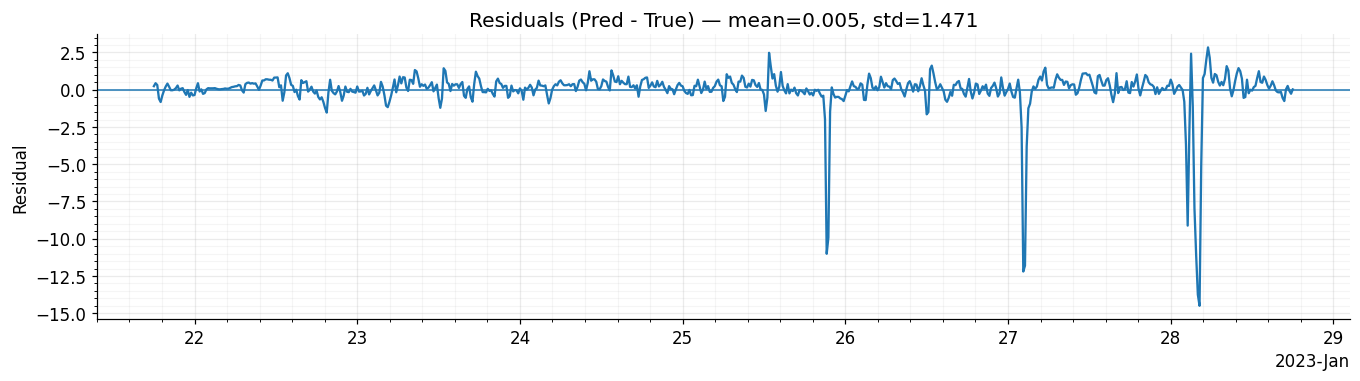

======= House 1 =========
Scaling columns: ['RH', 'Tout']
Epoch 1: Loss = 252.0425
✅ Saved best model at epoch 1 → models/df_1\best_rh.pt
Epoch 2: Loss = 93.6948
✅ Saved best model at epoch 2 → models/df_1\best_rh.pt
Epoch 3: Loss = 93.6946
✅ Saved best model at epoch 3 → models/df_1\best_rh.pt
Epoch 4: Loss = 80.2831
✅ Saved best model at epoch 4 → models/df_1\best_rh.pt
Epoch 5: Loss = 16.1254
✅ Saved best model at epoch 5 → models/df_1\best_rh.pt
Epoch 6: Loss = 5.8833
✅ Saved best model at epoch 6 → models/df_1\best_rh.pt
Epoch 7: Loss = 3.2973
✅ Saved best model at epoch 7 → models/df_1\best_rh.pt
Epoch 8: Loss = 2.2091
✅ Saved best model at epoch 8 → models/df_1\best_rh.pt
Epoch 9: Loss = 1.6910
✅ Saved best model at epoch 9 → models/df_1\best_rh.pt
Epoch 10: Loss = 1.4224
✅ Saved best model at epoch 10 → models/df_1\best_rh.pt
Epoch 11: Loss = 1.2823
✅ Saved best model at epoch 11 → models/df_1\best_rh.pt
Epoch 12: Loss = 1.1831
✅ Saved best model at epoch 12 → models/df_1\best_

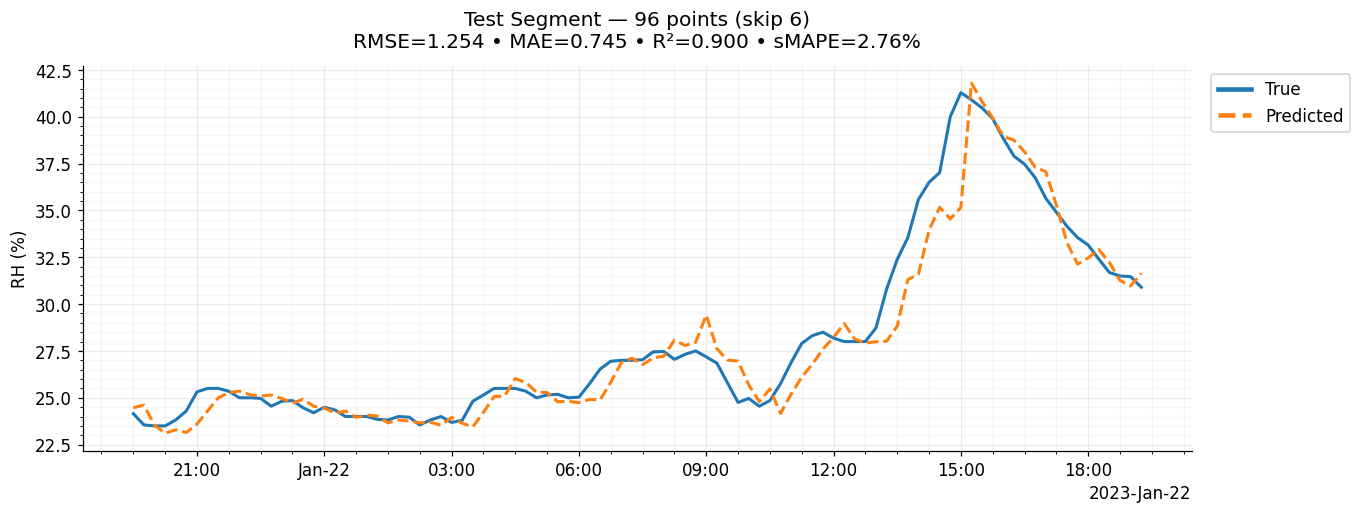

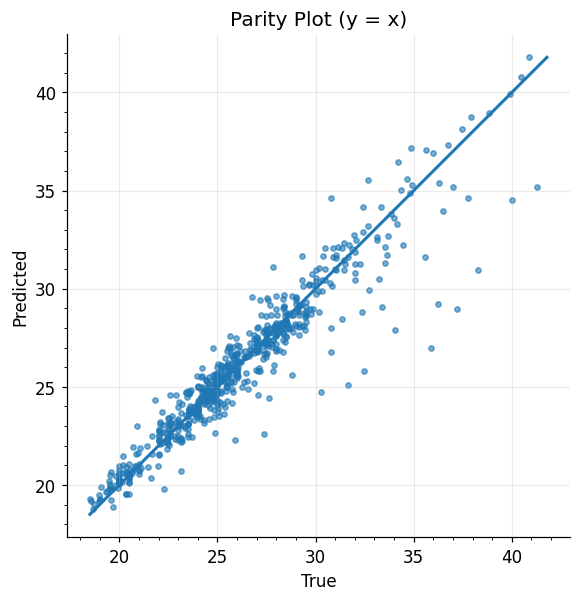

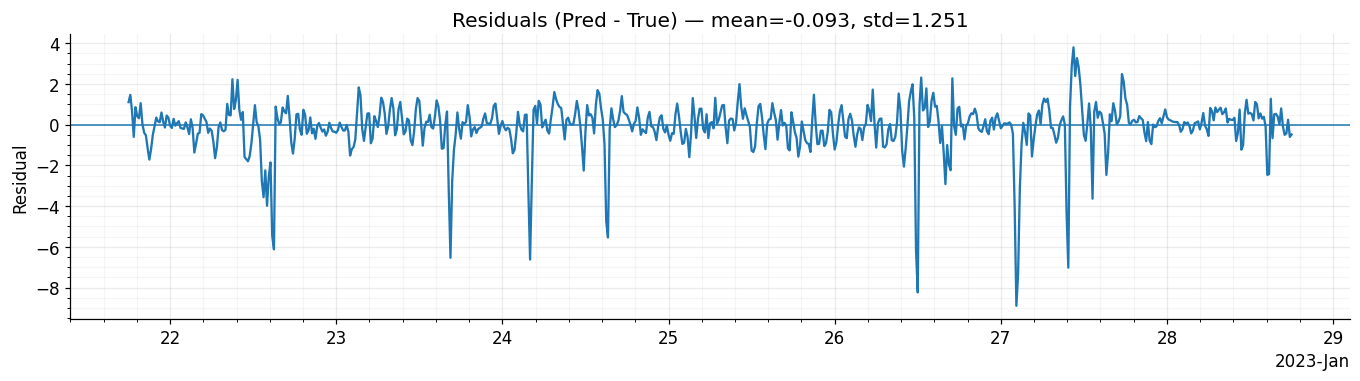

======= House 2 =========
Scaling columns: ['RH', 'Tout']
Epoch 1: Loss = 602.3007
✅ Saved best model at epoch 1 → models/df_2\best_rh.pt
Epoch 2: Loss = 172.1076
✅ Saved best model at epoch 2 → models/df_2\best_rh.pt
Epoch 3: Loss = 168.4973
✅ Saved best model at epoch 3 → models/df_2\best_rh.pt
Epoch 4: Loss = 168.4736
✅ Saved best model at epoch 4 → models/df_2\best_rh.pt
Epoch 5: Loss = 168.5270
Epoch 6: Loss = 151.0975
✅ Saved best model at epoch 6 → models/df_2\best_rh.pt
Epoch 7: Loss = 16.7702
✅ Saved best model at epoch 7 → models/df_2\best_rh.pt
Epoch 8: Loss = 4.4606
✅ Saved best model at epoch 8 → models/df_2\best_rh.pt
Epoch 9: Loss = 2.6344
✅ Saved best model at epoch 9 → models/df_2\best_rh.pt
Epoch 10: Loss = 2.0146
✅ Saved best model at epoch 10 → models/df_2\best_rh.pt
Epoch 11: Loss = 1.7883
✅ Saved best model at epoch 11 → models/df_2\best_rh.pt
Epoch 12: Loss = 1.6691
✅ Saved best model at epoch 12 → models/df_2\best_rh.pt
Epoch 13: Loss = 1.5779
✅ Saved best model

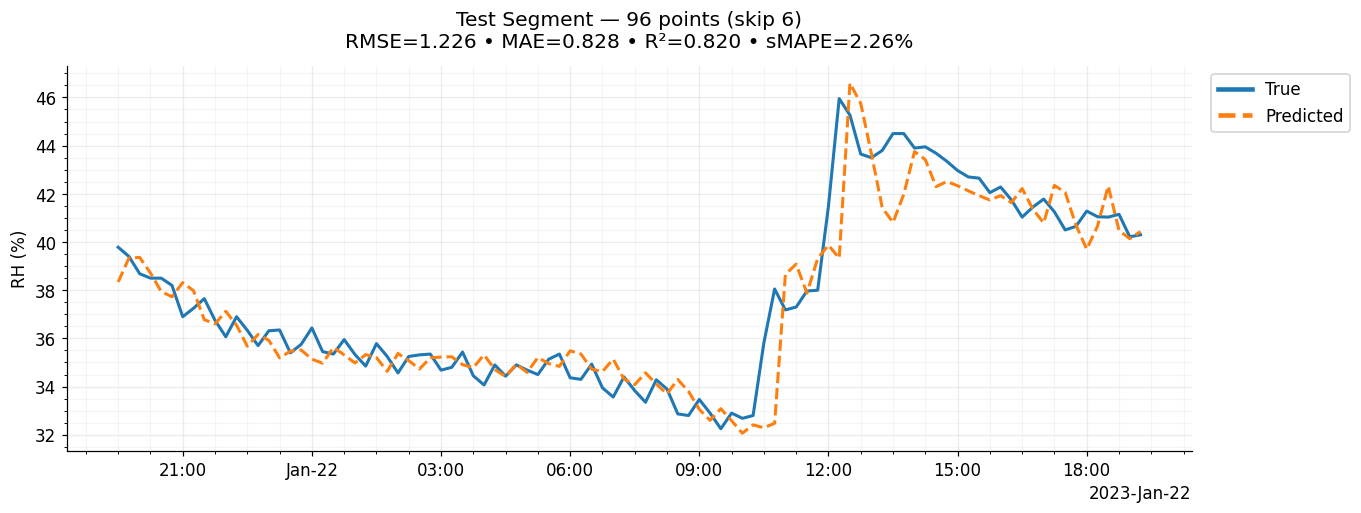

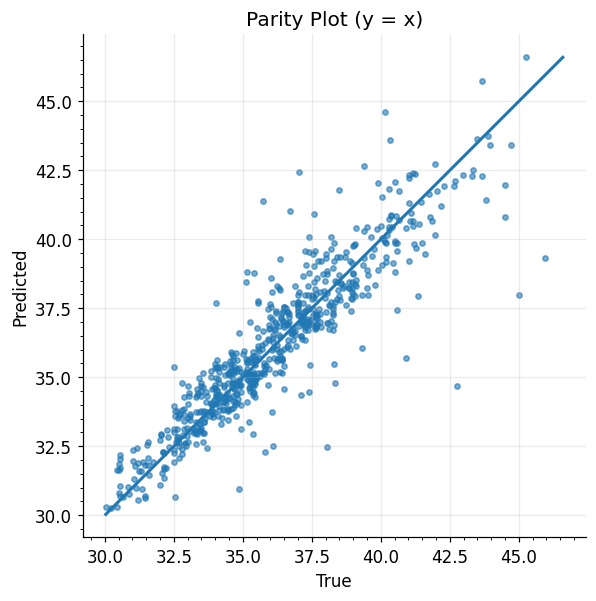

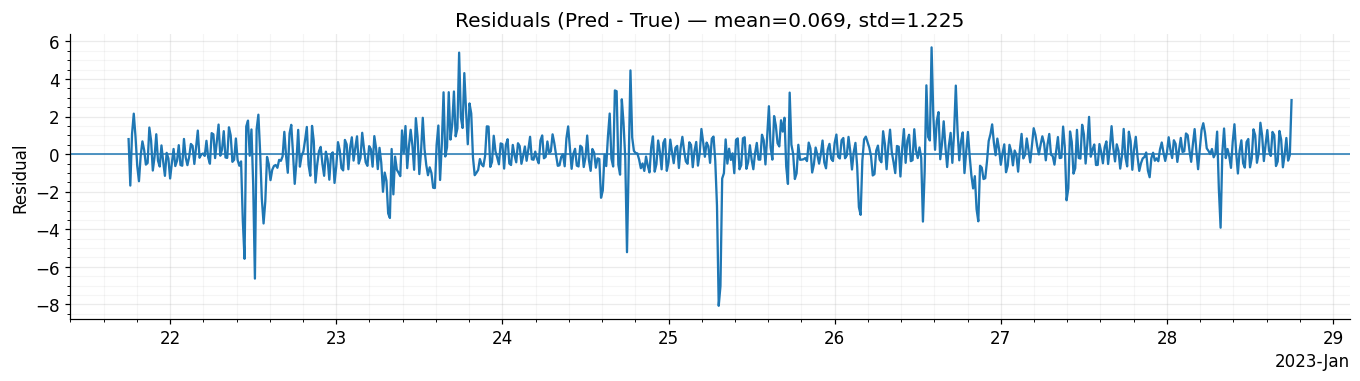

======= House 3 =========
Scaling columns: ['RH', 'Tout']
Epoch 1: Loss = 462.3759
✅ Saved best model at epoch 1 → models/df_3\best_rh.pt
Epoch 2: Loss = 247.5156
✅ Saved best model at epoch 2 → models/df_3\best_rh.pt
Epoch 3: Loss = 247.3513
✅ Saved best model at epoch 3 → models/df_3\best_rh.pt
Epoch 4: Loss = 105.7665
✅ Saved best model at epoch 4 → models/df_3\best_rh.pt
Epoch 5: Loss = 9.5193
✅ Saved best model at epoch 5 → models/df_3\best_rh.pt
Epoch 6: Loss = 2.7879
✅ Saved best model at epoch 6 → models/df_3\best_rh.pt
Epoch 7: Loss = 1.4739
✅ Saved best model at epoch 7 → models/df_3\best_rh.pt
Epoch 8: Loss = 1.1106
✅ Saved best model at epoch 8 → models/df_3\best_rh.pt
Epoch 9: Loss = 0.9614
✅ Saved best model at epoch 9 → models/df_3\best_rh.pt
Epoch 10: Loss = 0.8636
✅ Saved best model at epoch 10 → models/df_3\best_rh.pt
Epoch 11: Loss = 0.8325
✅ Saved best model at epoch 11 → models/df_3\best_rh.pt
Epoch 12: Loss = 0.7833
✅ Saved best model at epoch 12 → models/df_3\bes

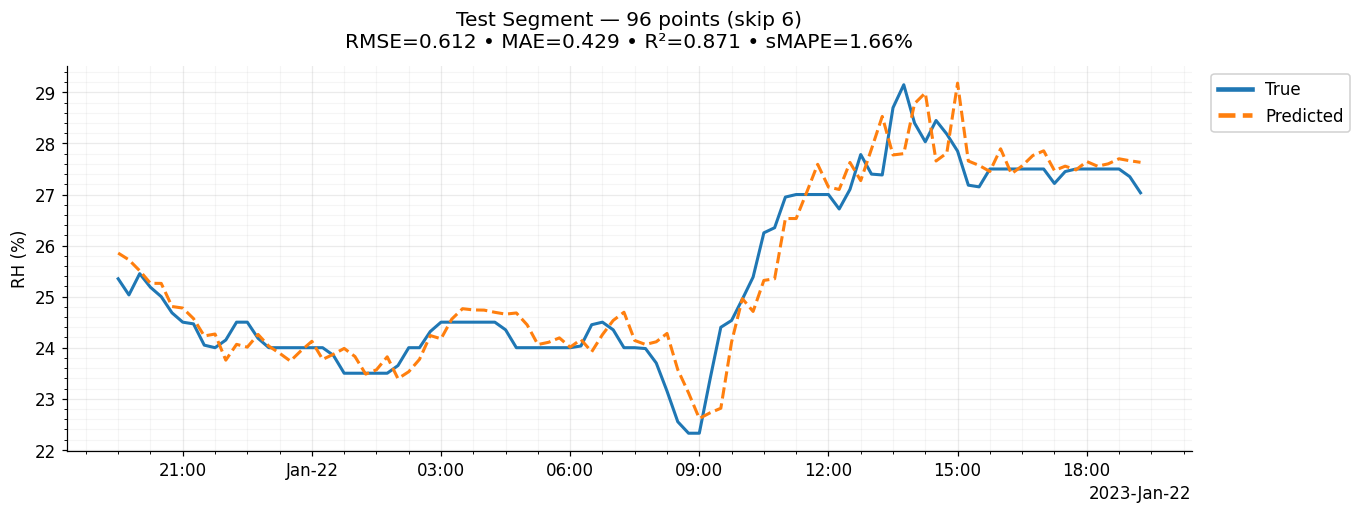

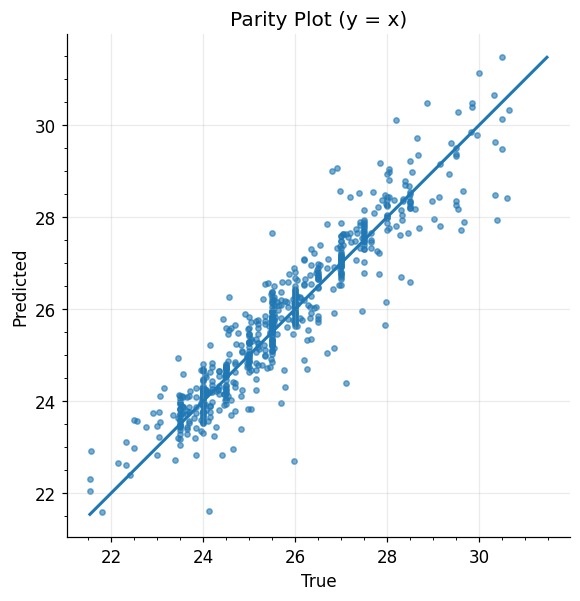

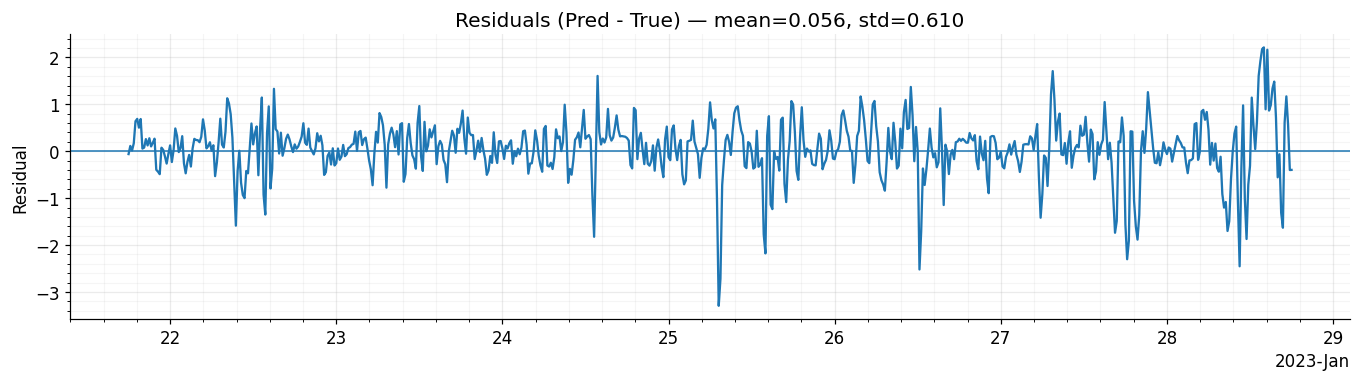

======= House 4 =========
Scaling columns: ['RH', 'Tout']
Epoch 1: Loss = 535.2827
✅ Saved best model at epoch 1 → models/df_4\best_rh.pt
Epoch 2: Loss = 241.3622
✅ Saved best model at epoch 2 → models/df_4\best_rh.pt
Epoch 3: Loss = 240.5325
✅ Saved best model at epoch 3 → models/df_4\best_rh.pt
Epoch 4: Loss = 240.5716
Epoch 5: Loss = 186.0906
✅ Saved best model at epoch 5 → models/df_4\best_rh.pt
Epoch 6: Loss = 12.7391
✅ Saved best model at epoch 6 → models/df_4\best_rh.pt
Epoch 7: Loss = 3.4806
✅ Saved best model at epoch 7 → models/df_4\best_rh.pt
Epoch 8: Loss = 2.1254
✅ Saved best model at epoch 8 → models/df_4\best_rh.pt
Epoch 9: Loss = 1.6147
✅ Saved best model at epoch 9 → models/df_4\best_rh.pt
Epoch 10: Loss = 1.4194
✅ Saved best model at epoch 10 → models/df_4\best_rh.pt
Epoch 11: Loss = 1.2325
✅ Saved best model at epoch 11 → models/df_4\best_rh.pt
Epoch 12: Loss = 1.1536
✅ Saved best model at epoch 12 → models/df_4\best_rh.pt
Epoch 13: Loss = 1.0576
✅ Saved best model a

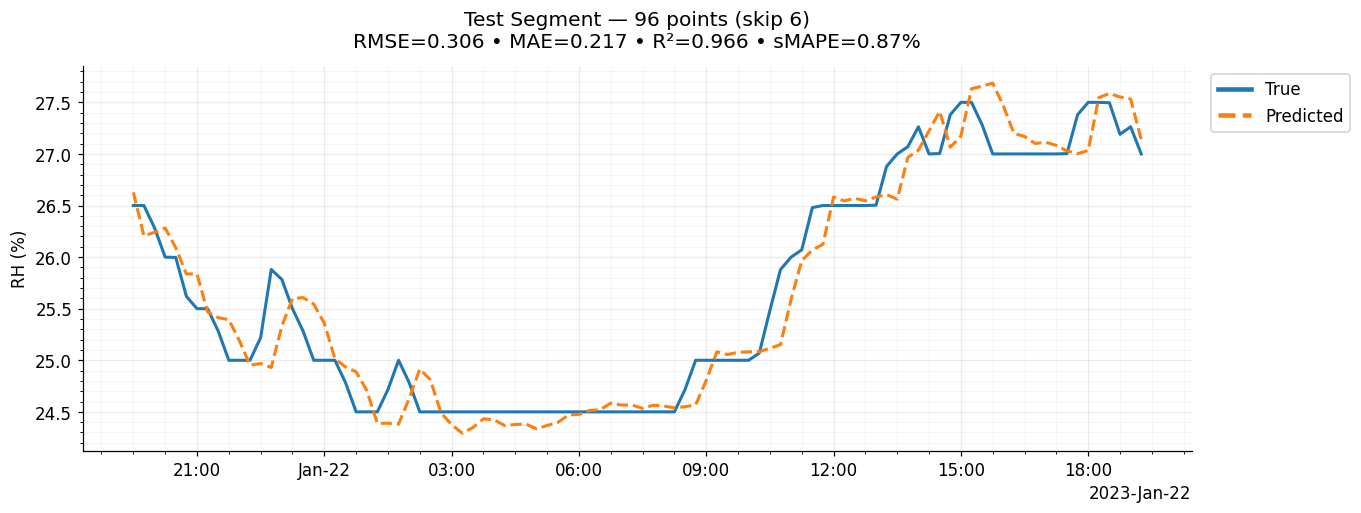

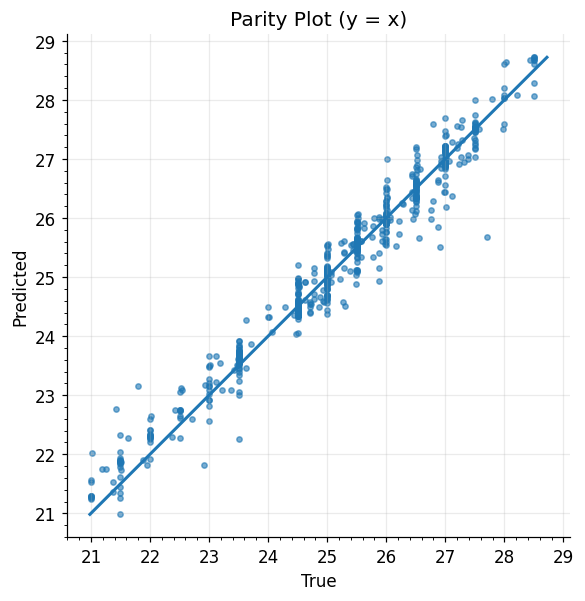

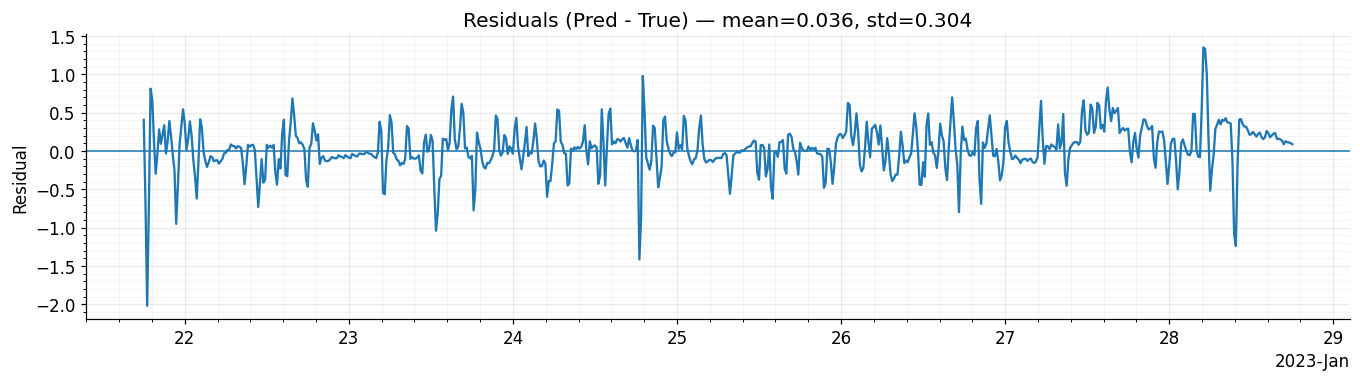

======= House 5 =========
Scaling columns: ['RH', 'Tout']
Epoch 1: Loss = 501.5845
✅ Saved best model at epoch 1 → models/df_5\best_rh.pt
Epoch 2: Loss = 228.5931
✅ Saved best model at epoch 2 → models/df_5\best_rh.pt
Epoch 3: Loss = 227.9054
✅ Saved best model at epoch 3 → models/df_5\best_rh.pt
Epoch 4: Loss = 227.8555
✅ Saved best model at epoch 4 → models/df_5\best_rh.pt
Epoch 5: Loss = 124.9039
✅ Saved best model at epoch 5 → models/df_5\best_rh.pt
Epoch 6: Loss = 8.1664
✅ Saved best model at epoch 6 → models/df_5\best_rh.pt
Epoch 7: Loss = 2.8416
✅ Saved best model at epoch 7 → models/df_5\best_rh.pt
Epoch 8: Loss = 1.7595
✅ Saved best model at epoch 8 → models/df_5\best_rh.pt
Epoch 9: Loss = 1.3359
✅ Saved best model at epoch 9 → models/df_5\best_rh.pt
Epoch 10: Loss = 1.1706
✅ Saved best model at epoch 10 → models/df_5\best_rh.pt
Epoch 11: Loss = 1.0505
✅ Saved best model at epoch 11 → models/df_5\best_rh.pt
Epoch 12: Loss = 0.9725
✅ Saved best model at epoch 12 → models/df_5\b

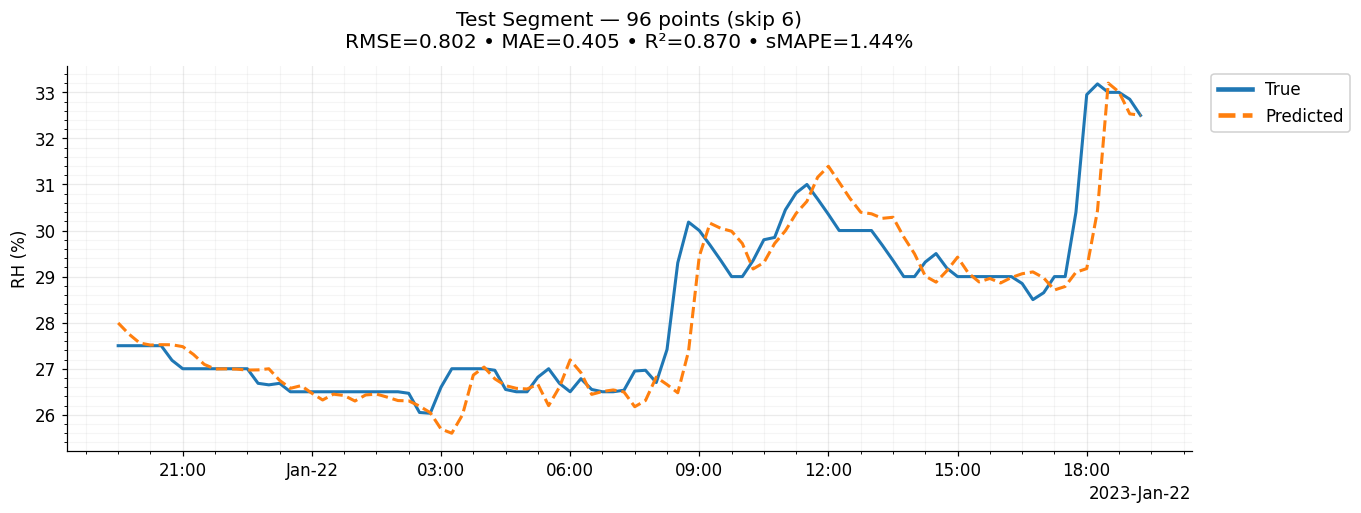

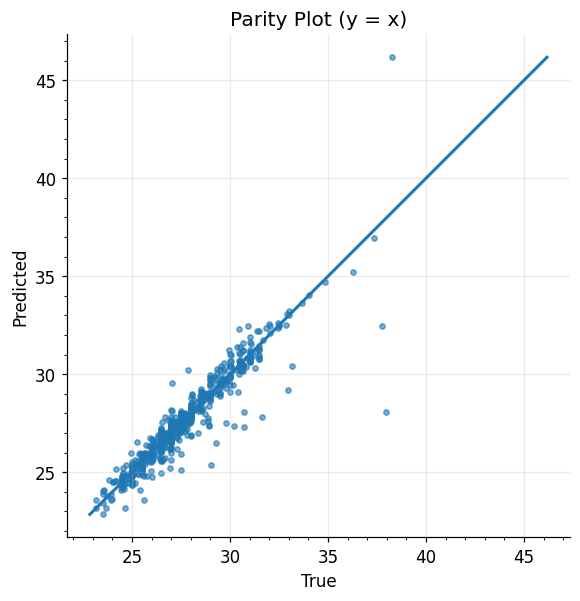

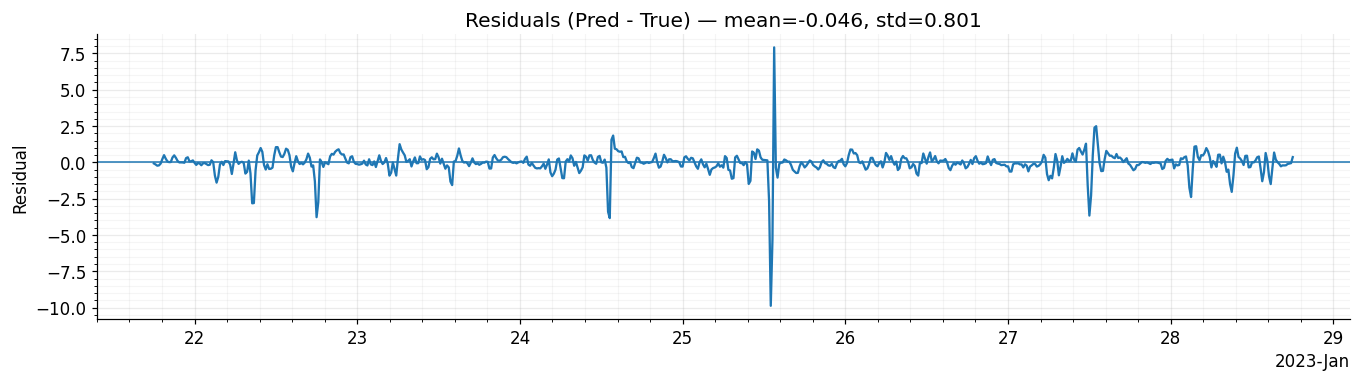

======= House 6 =========
Scaling columns: ['RH', 'Tout']
Epoch 1: Loss = 572.4898
✅ Saved best model at epoch 1 → models/df_6\best_rh.pt
Epoch 2: Loss = 276.4218
✅ Saved best model at epoch 2 → models/df_6\best_rh.pt
Epoch 3: Loss = 275.4160
✅ Saved best model at epoch 3 → models/df_6\best_rh.pt
Epoch 4: Loss = 275.4437
Epoch 5: Loss = 107.3434
✅ Saved best model at epoch 5 → models/df_6\best_rh.pt
Epoch 6: Loss = 9.1132
✅ Saved best model at epoch 6 → models/df_6\best_rh.pt
Epoch 7: Loss = 4.3729
✅ Saved best model at epoch 7 → models/df_6\best_rh.pt
Epoch 8: Loss = 2.9620
✅ Saved best model at epoch 8 → models/df_6\best_rh.pt
Epoch 9: Loss = 2.3037
✅ Saved best model at epoch 9 → models/df_6\best_rh.pt
Epoch 10: Loss = 1.8439
✅ Saved best model at epoch 10 → models/df_6\best_rh.pt
Epoch 11: Loss = 1.6278
✅ Saved best model at epoch 11 → models/df_6\best_rh.pt
Epoch 12: Loss = 1.4153
✅ Saved best model at epoch 12 → models/df_6\best_rh.pt
Epoch 13: Loss = 1.3146
✅ Saved best model at

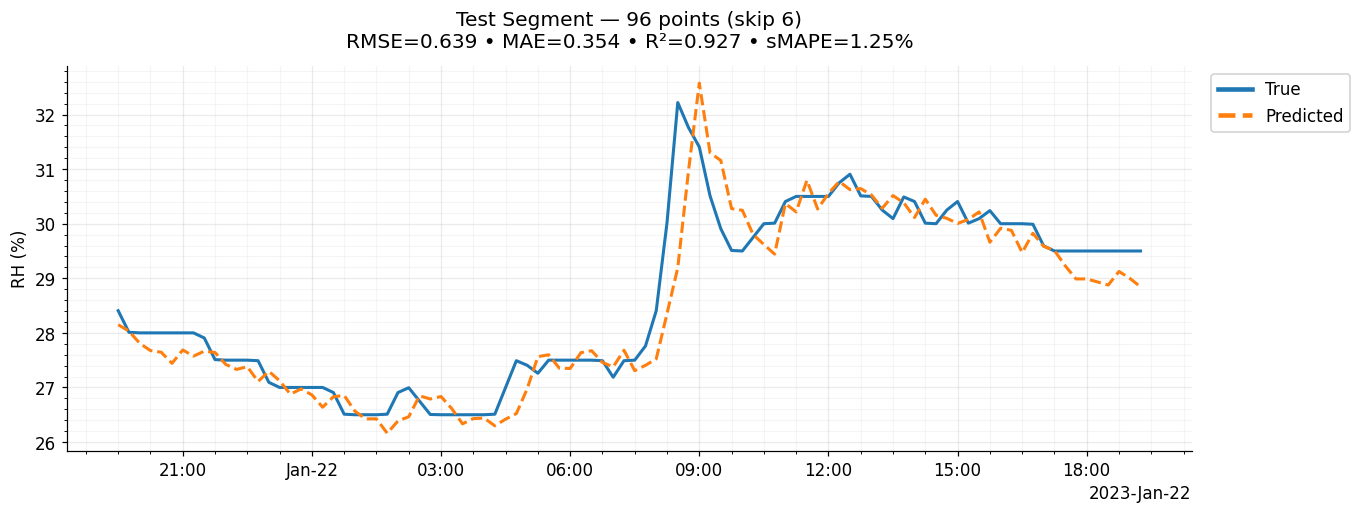

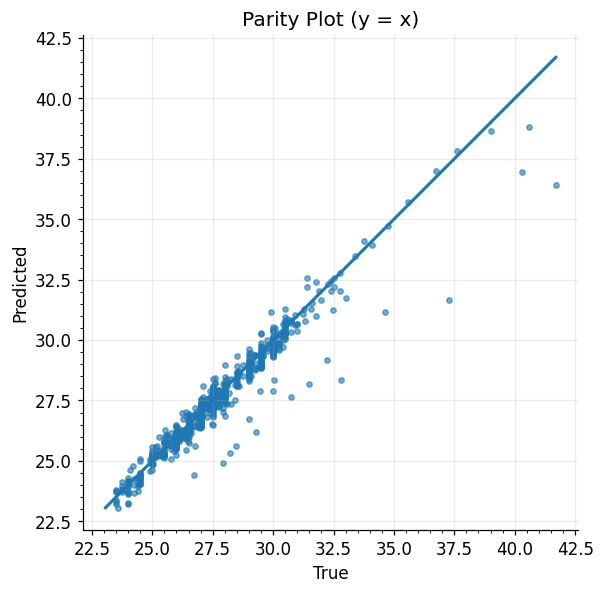

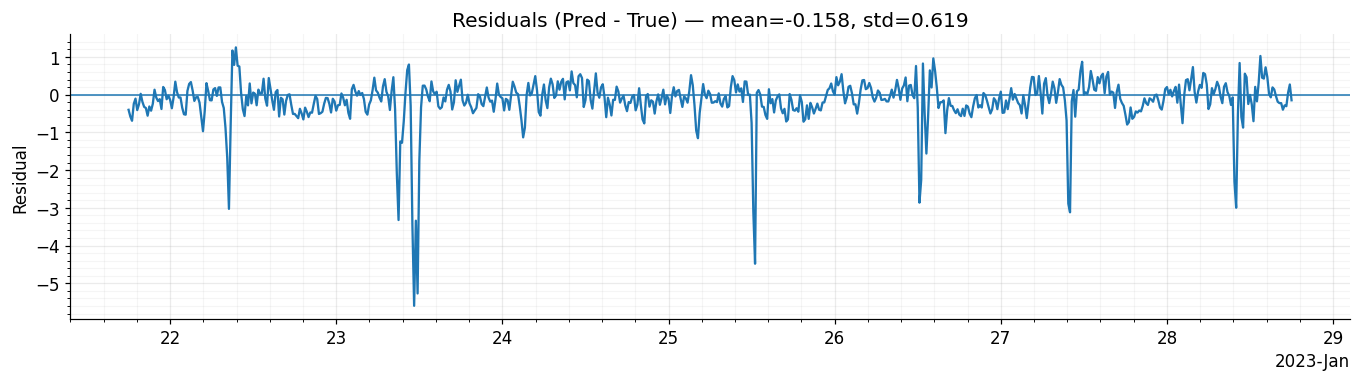

======= House 7 =========
Scaling columns: ['RH', 'Tout']
Epoch 1: Loss = 514.0847
✅ Saved best model at epoch 1 → models/df_7\best_rh.pt
Epoch 2: Loss = 230.7543
✅ Saved best model at epoch 2 → models/df_7\best_rh.pt
Epoch 3: Loss = 230.0551
✅ Saved best model at epoch 3 → models/df_7\best_rh.pt
Epoch 4: Loss = 230.0632
Epoch 5: Loss = 230.0550
✅ Saved best model at epoch 5 → models/df_7\best_rh.pt
Epoch 6: Loss = 184.6860
✅ Saved best model at epoch 6 → models/df_7\best_rh.pt
Epoch 7: Loss = 11.0066
✅ Saved best model at epoch 7 → models/df_7\best_rh.pt
Epoch 8: Loss = 2.8876
✅ Saved best model at epoch 8 → models/df_7\best_rh.pt
Epoch 9: Loss = 1.9928
✅ Saved best model at epoch 9 → models/df_7\best_rh.pt
Epoch 10: Loss = 1.7191
✅ Saved best model at epoch 10 → models/df_7\best_rh.pt
Epoch 11: Loss = 1.6156
✅ Saved best model at epoch 11 → models/df_7\best_rh.pt
Epoch 12: Loss = 1.4624
✅ Saved best model at epoch 12 → models/df_7\best_rh.pt
Epoch 13: Loss = 1.4181
✅ Saved best model

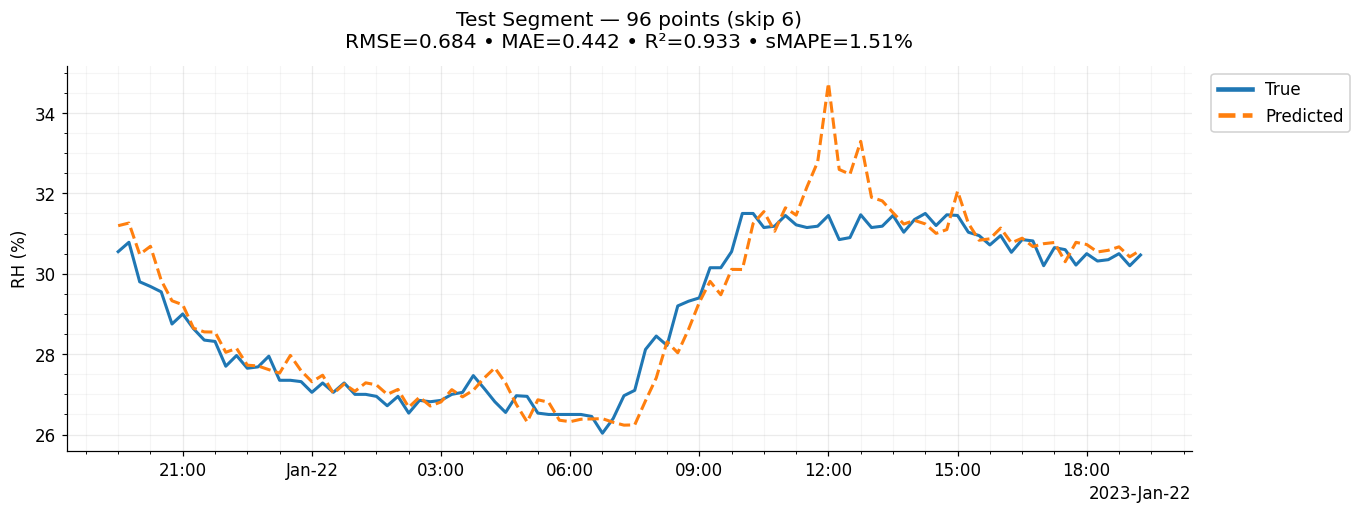

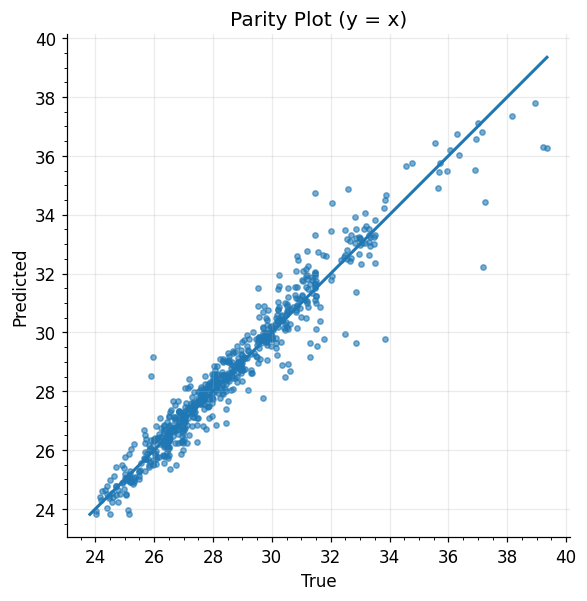

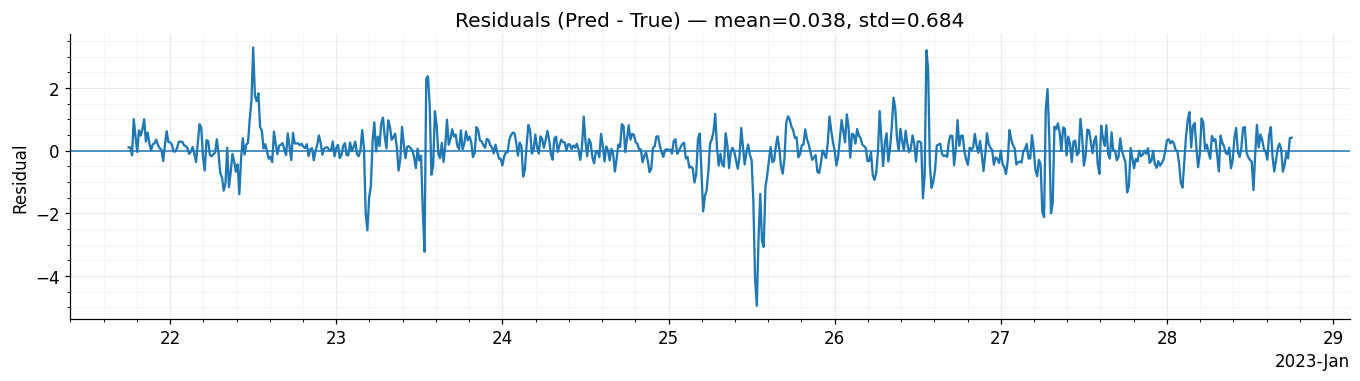

In [7]:
for index,df in enumerate(dfs):
    print(f"======= House {index} =========")

    df['RH_lag1'] = df['RH'].shift(1)
    df['RH_lag2'] = df['RH'].shift(2)
    df['RH_lag3'] = df['RH'].shift(3)
    df['RH_lag4'] = df['RH'].shift(4)
    # for lag in range(1,8):
    #     df[f'RH_lag{lag}'] = df['RH'].shift(lag)
    df['RH_target'] = df['RH'].shift(-1)

    df_encoded = pd.get_dummies(df, columns=['hvac_mode'], prefix='hvac')

    rh_input_cols = [
        'RH', 
        'Tout', 'hvac_0', 'hvac_1', 'hvac_2', 'hour_sin', 'hour_cos'
    ]

    for col in ['hvac_0', 'hvac_1', 'hvac_2']:
        if col not in df_encoded.columns:
            df_encoded[col] = 0

    required_cols_rh = rh_input_cols + ['RH_target']
    nan_mask_rh = df_encoded[required_cols_rh].isnull().any(axis=1)
    df_clean_rh = df_encoded[~nan_mask_rh].copy()

    save_dir = f"models/df_{index}"
    save_scaler_dir =  f"models/scalers/df_{index}"
    os.makedirs(save_scaler_dir, exist_ok=True)
    scaler_path = os.path.join(save_scaler_dir, 'scaler_rh.pk1')

    model_rh, scaler_rh, dataset_rh = train_lstm_model(
        df_clean_rh,
        input_cols=rh_input_cols,
        target_col='RH_target', window_size=24, batch_size=64, use_scaler=True, epochs=100, hidden_size=128, num_layers=2, lr=0.001, save_dir=save_dir
    )

    joblib.dump(scaler_rh, scaler_path)


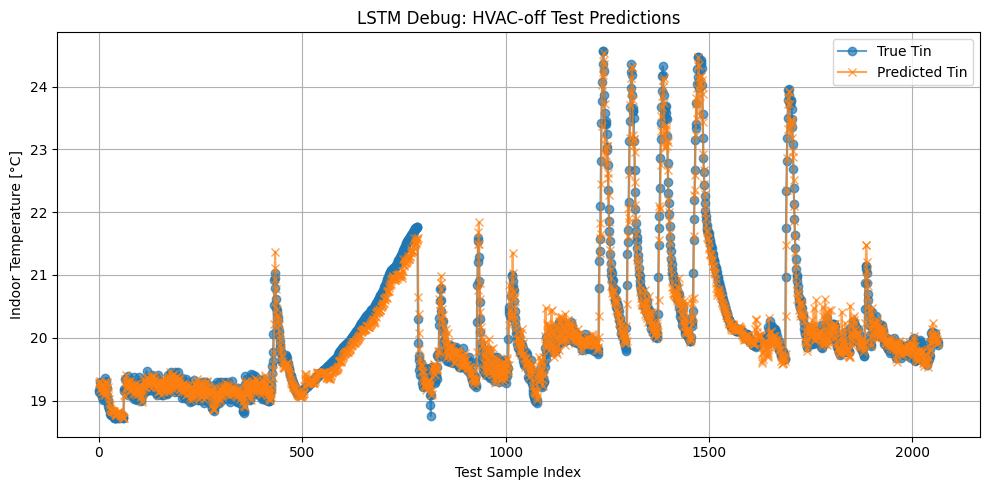

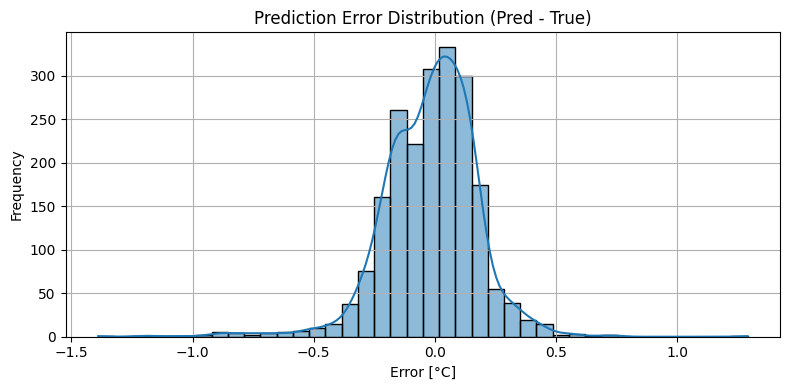

Mean error: -0.018 °C
RMSE: 0.197 °C
Predicted Tin range: 18.72 – 24.53
True Tin range: 18.72 – 24.57


In [ ]:
import seaborn as sns

def debug_plot_lstm_predictions(model, dataset, df_raw, input_cols, title='LSTM Debug: HVAC-off Test Predictions'):
    model.eval()

    test_idx = np.where(dataset.is_test_flags == True)[0]
    if len(test_idx) == 0:
        print("No test data in dataset.")
        return

    test_X = dataset.X_seq[test_idx]
    test_y = dataset.y[test_idx]

    with torch.no_grad():
        pred_y = model(test_X).numpy()
        true_y = test_y.numpy()

    # Plot predicted vs true
    plt.figure(figsize=(10, 5))
    plt.plot(true_y, label='True Tin', marker='o', alpha=0.7)
    plt.plot(pred_y, label='Predicted Tin', marker='x', alpha=0.7)
    plt.xlabel('Test Sample Index')
    plt.ylabel('Indoor Temperature [°C]')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot error distribution
    errors = pred_y - true_y
    plt.figure(figsize=(8, 4))
    sns.histplot(errors, bins=40, kde=True)
    plt.title("Prediction Error Distribution (Pred - True)")
    plt.xlabel("Error [°C]")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Print some stats
    print(f"Mean error: {np.mean(errors):.3f} °C")
    print(f"RMSE: {np.sqrt(np.mean(errors**2)):.3f} °C")
    print(f"Predicted Tin range: {pred_y.min():.2f} – {pred_y.max():.2f}")
    print(f"True Tin range: {true_y.min():.2f} – {true_y.max():.2f}")

debug_plot_lstm_predictions(model, dataset, df_raw=df_off, input_cols=input_cols)

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MAE: 0.1692592117669
Test MAE: 0.054 °C
Test MAPE: 0.277 %
[df_0] Saved best RF model → models/df_0\best_model_rf.pk1

               Performance Metrics             
   Metric  Value
     RMSE 0.0648
      MAE 0.0536
       R² 0.6862
sMAPE (%) 0.2771



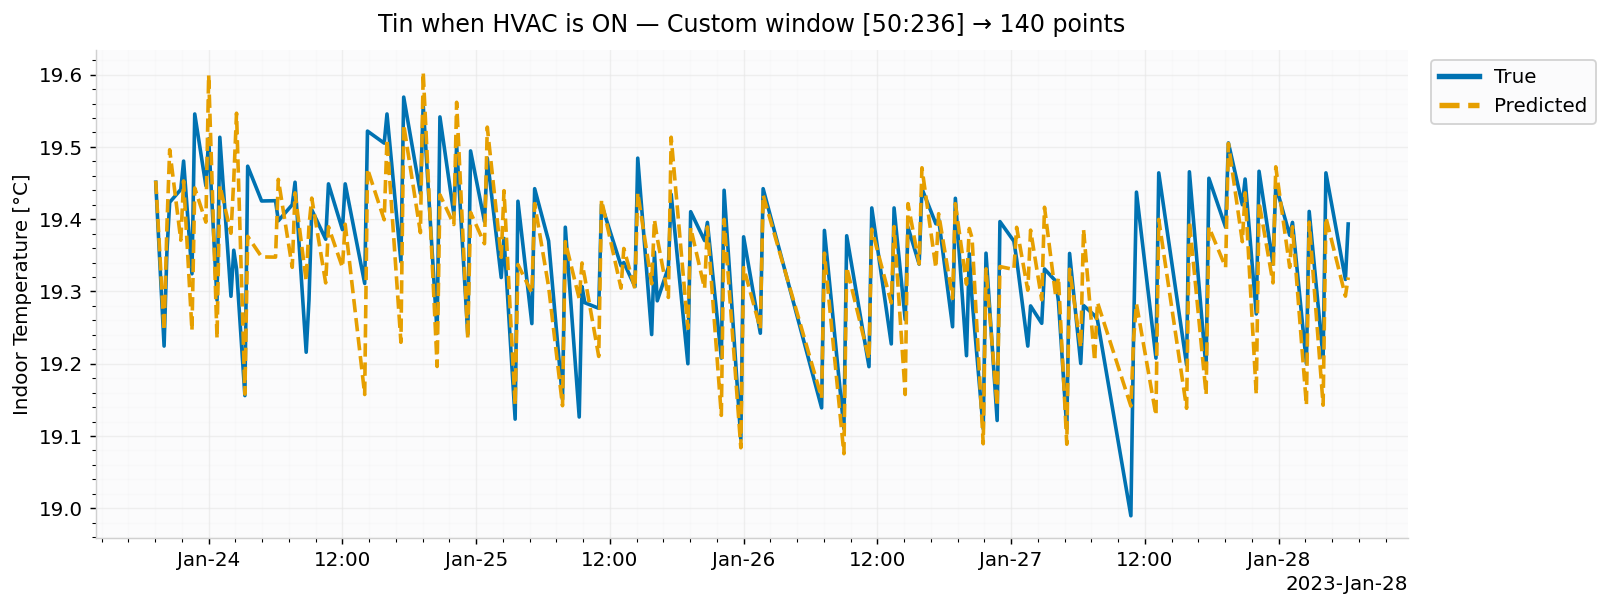

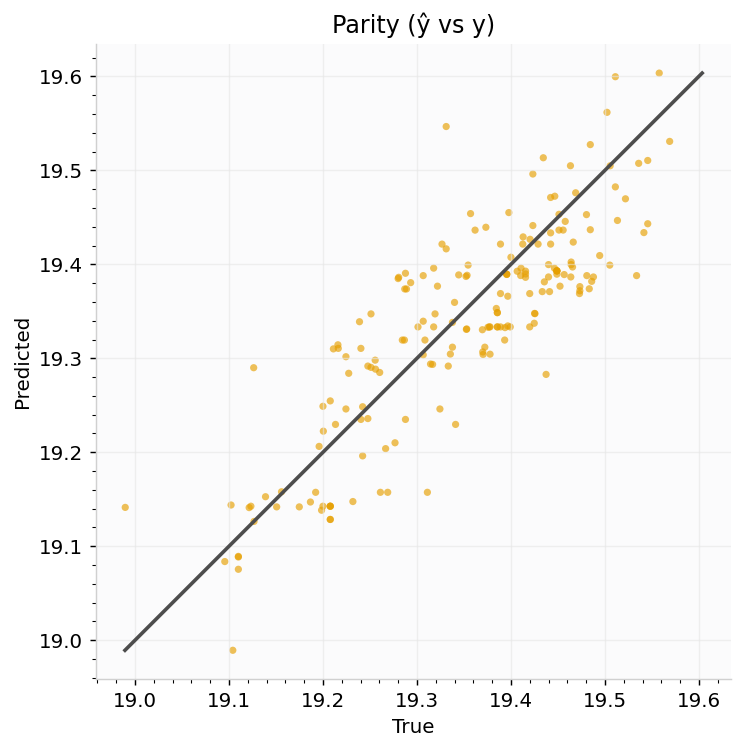

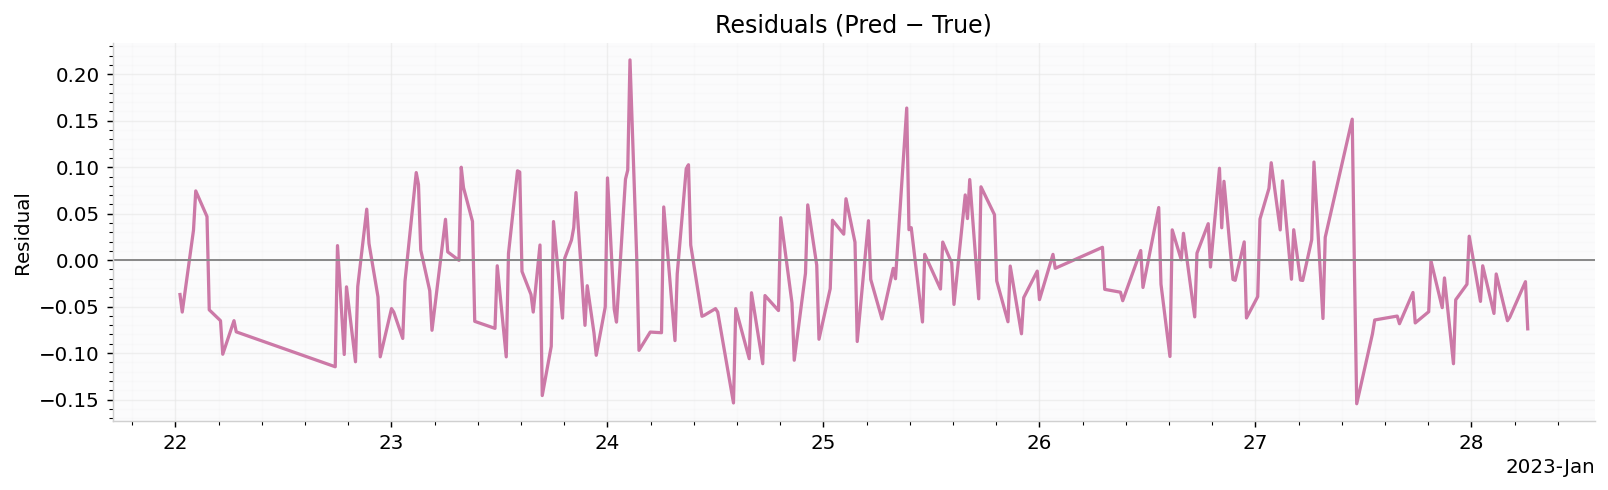

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 7, 'min_samples_split': 10, 'n_estimators': 200}
Best CV MAE: 0.15284266424991896
Test MAE: 0.216 °C
Test MAPE: 0.949 %
[df_1] Saved best RF model → models/df_1\best_model_rf.pk1

               Performance Metrics             
   Metric  Value
     RMSE 0.2731
      MAE 0.2158
       R² 0.9512
sMAPE (%) 0.9480



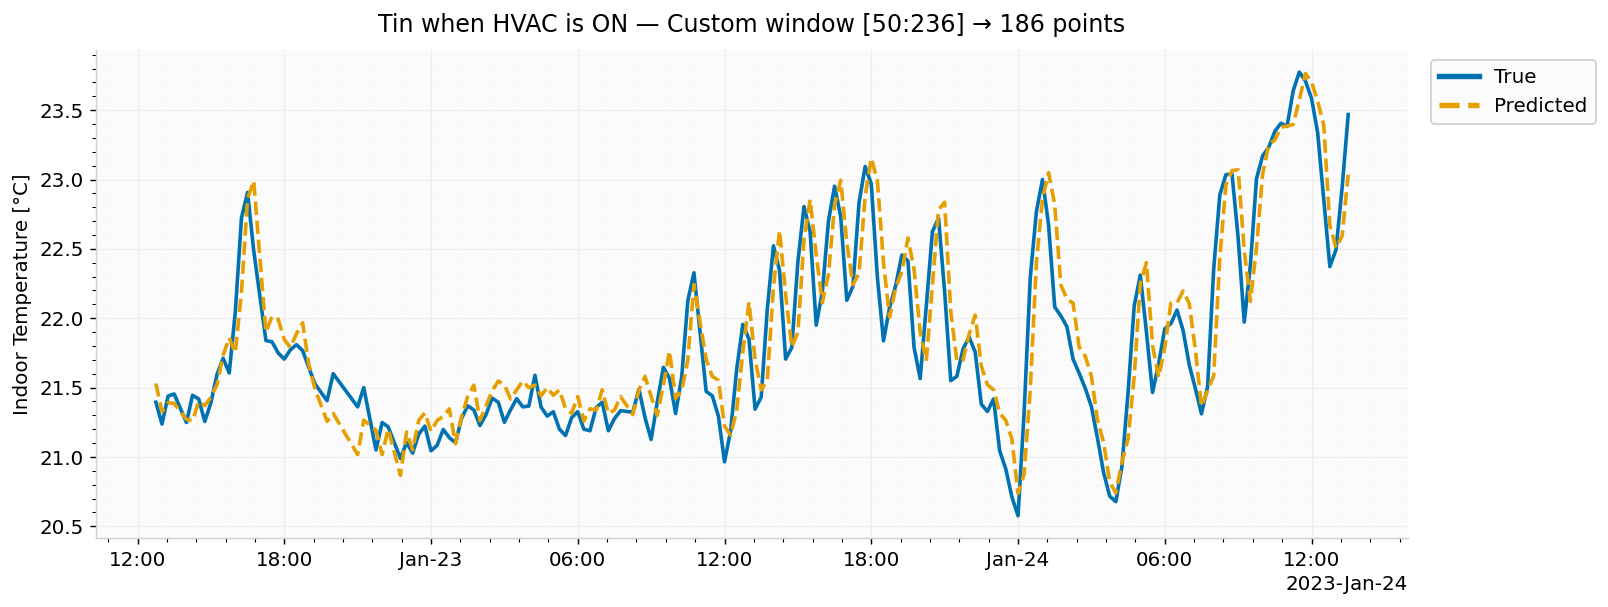

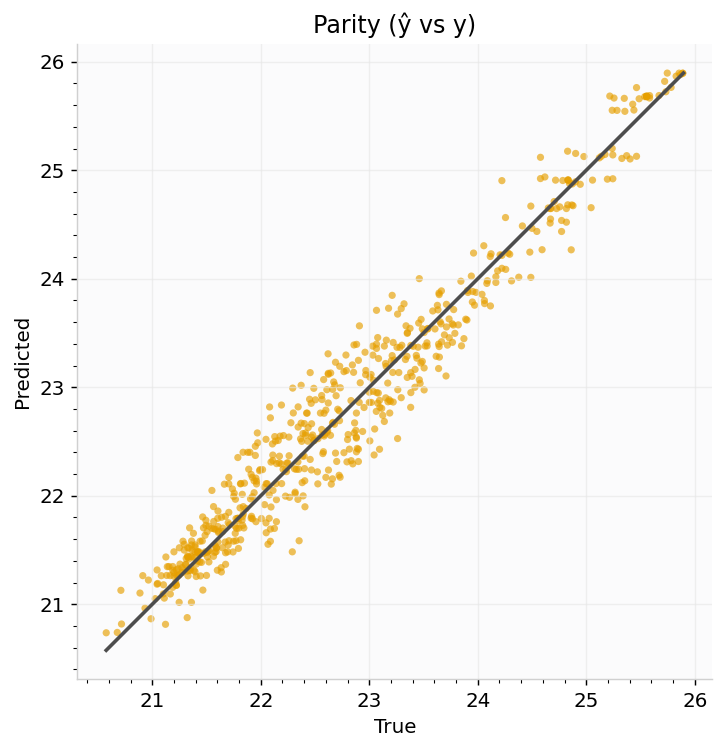

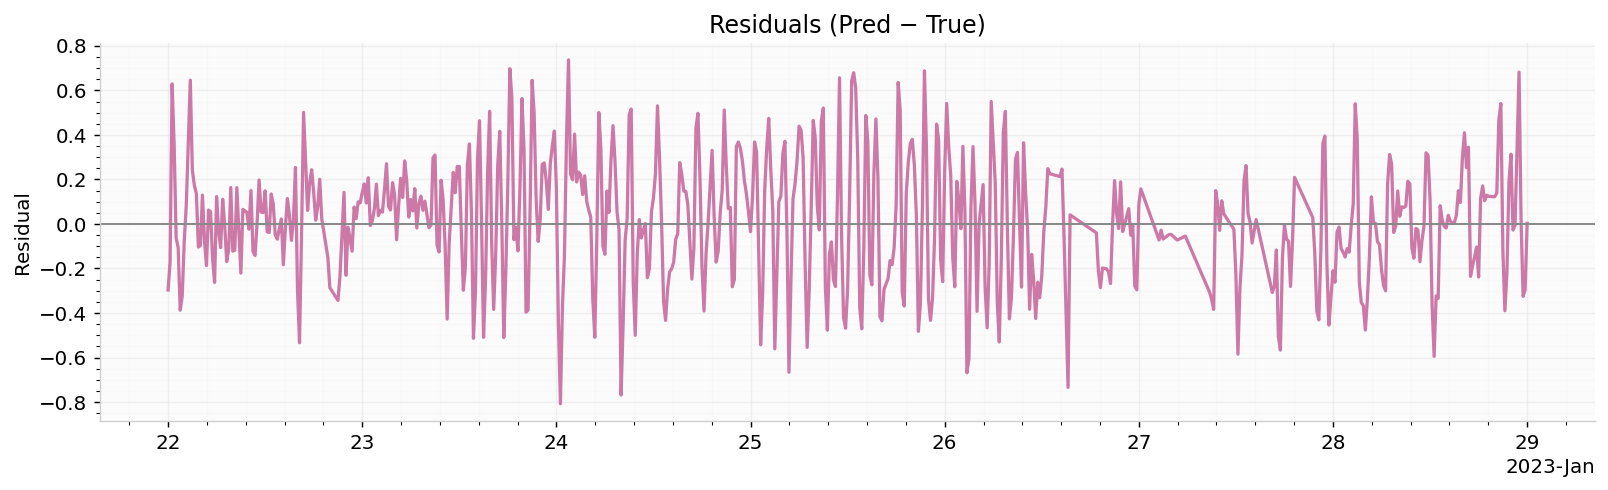

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV MAE: 0.19205483169736007
Test MAE: 0.119 °C
Test MAPE: 0.592 %
[df_2] Saved best RF model → models/df_2\best_model_rf.pk1

               Performance Metrics             
   Metric  Value
     RMSE 0.1395
      MAE 0.1187
       R² 0.6212
sMAPE (%) 0.5909



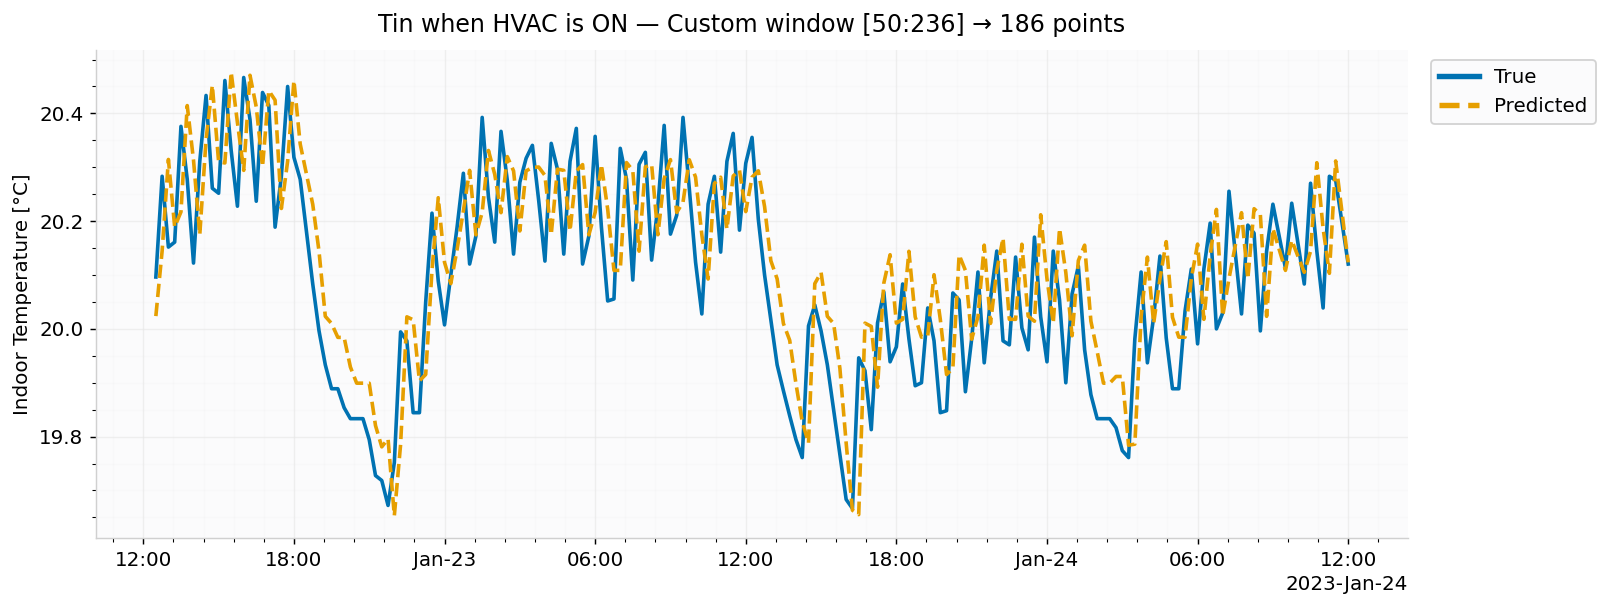

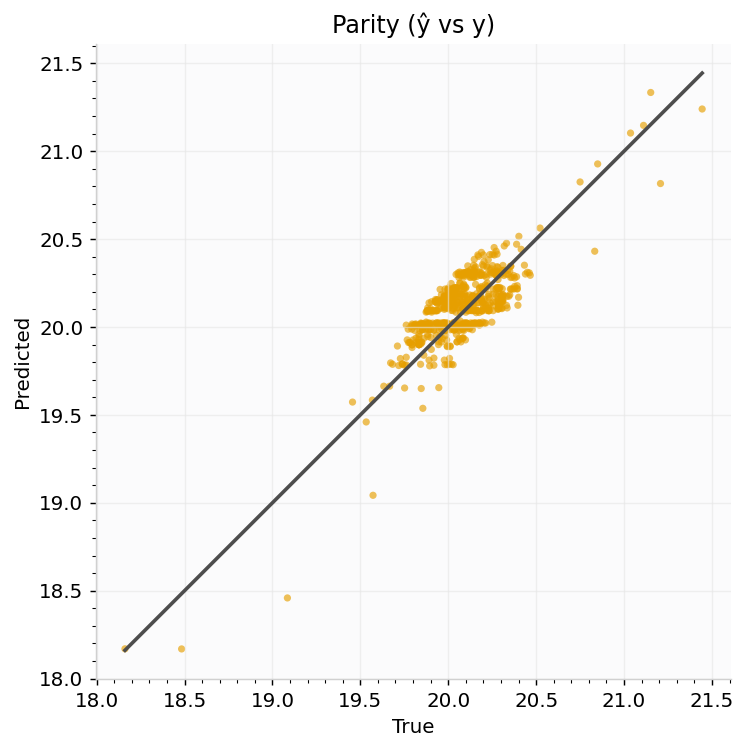

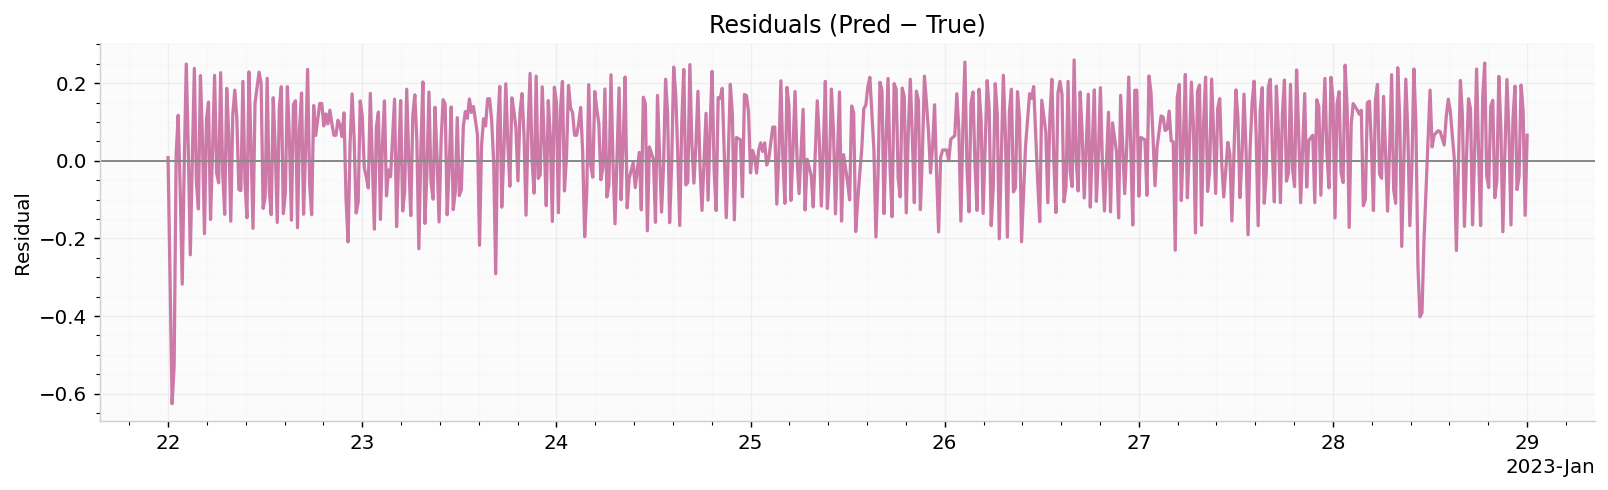

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best CV MAE: 0.15285354161479212
Test MAE: 0.119 °C
Test MAPE: 0.520 %
[df_3] Saved best RF model → models/df_3\best_model_rf.pk1

               Performance Metrics             
   Metric  Value
     RMSE 0.1541
      MAE 0.1187
       R² 0.7573
sMAPE (%) 0.5186



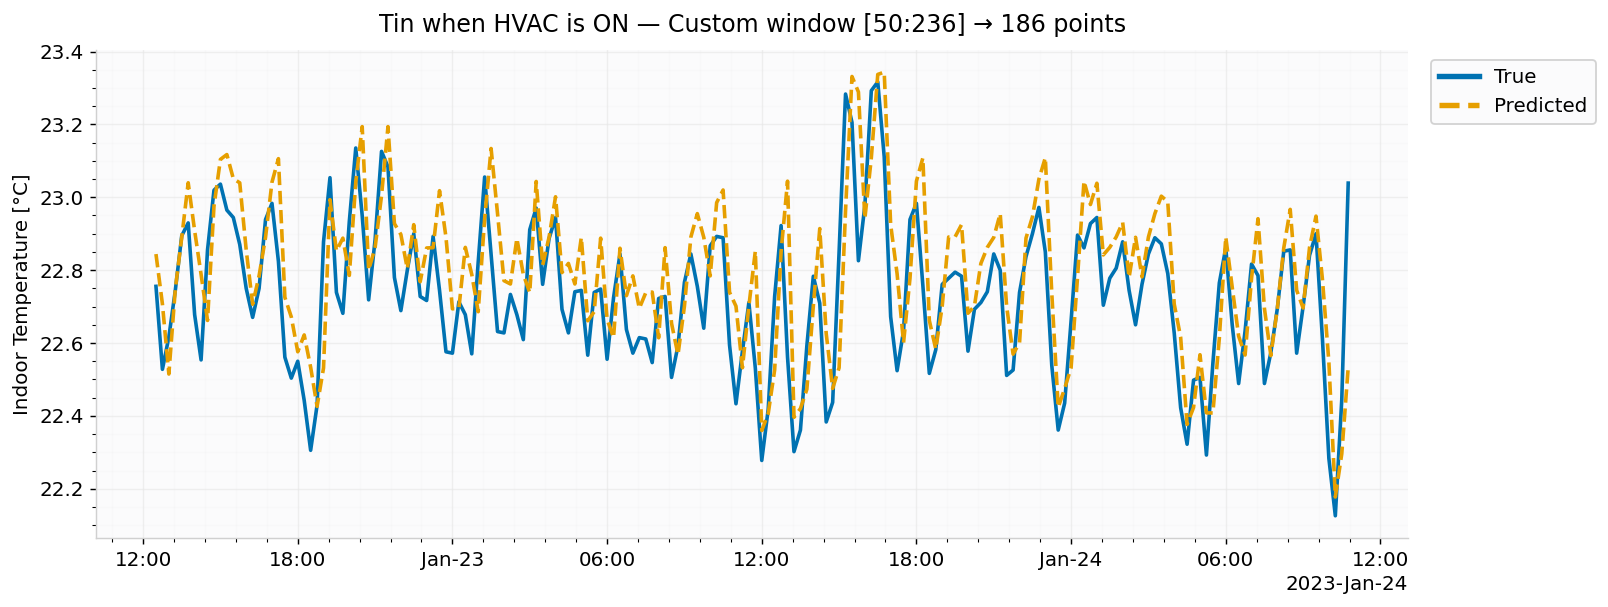

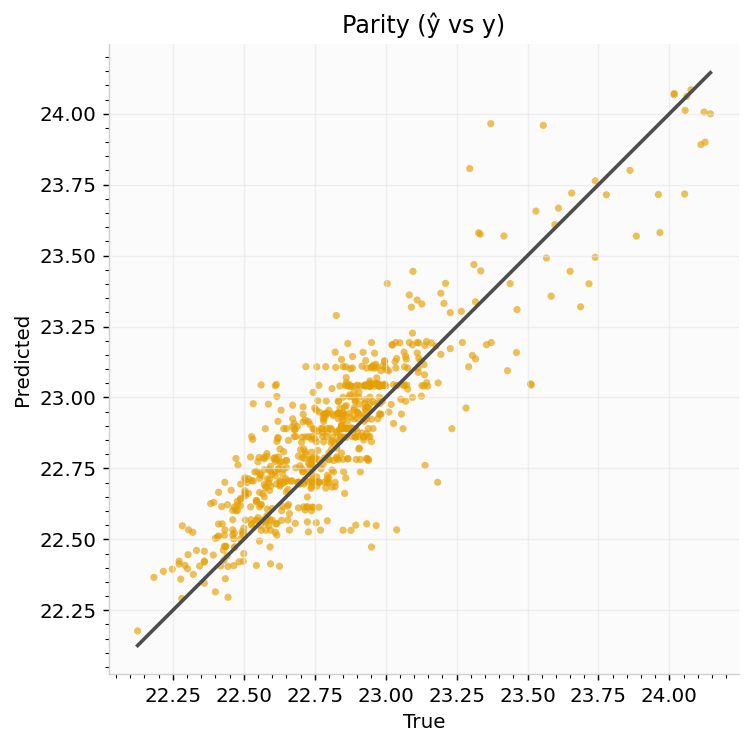

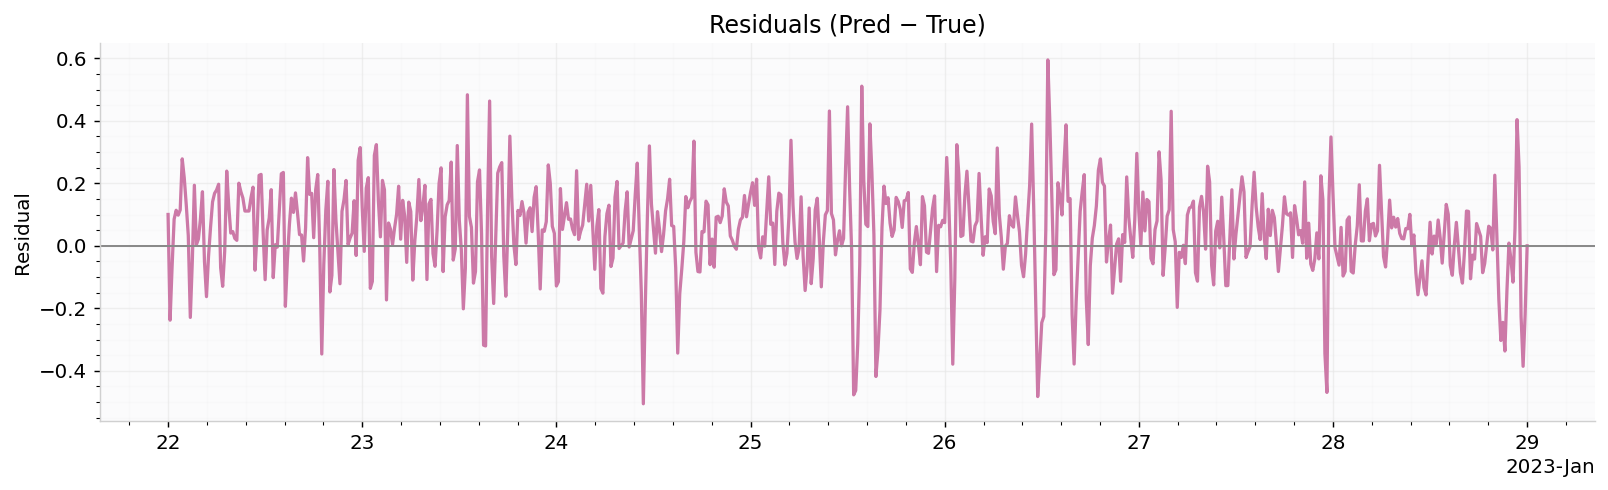

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MAE: 0.10453471136951838
Test MAE: 0.078 °C
Test MAPE: 0.363 %
[df_4] Saved best RF model → models/df_4\best_model_rf.pk1

               Performance Metrics             
   Metric  Value
     RMSE 0.1010
      MAE 0.0777
       R² 0.7058
sMAPE (%) 0.3643



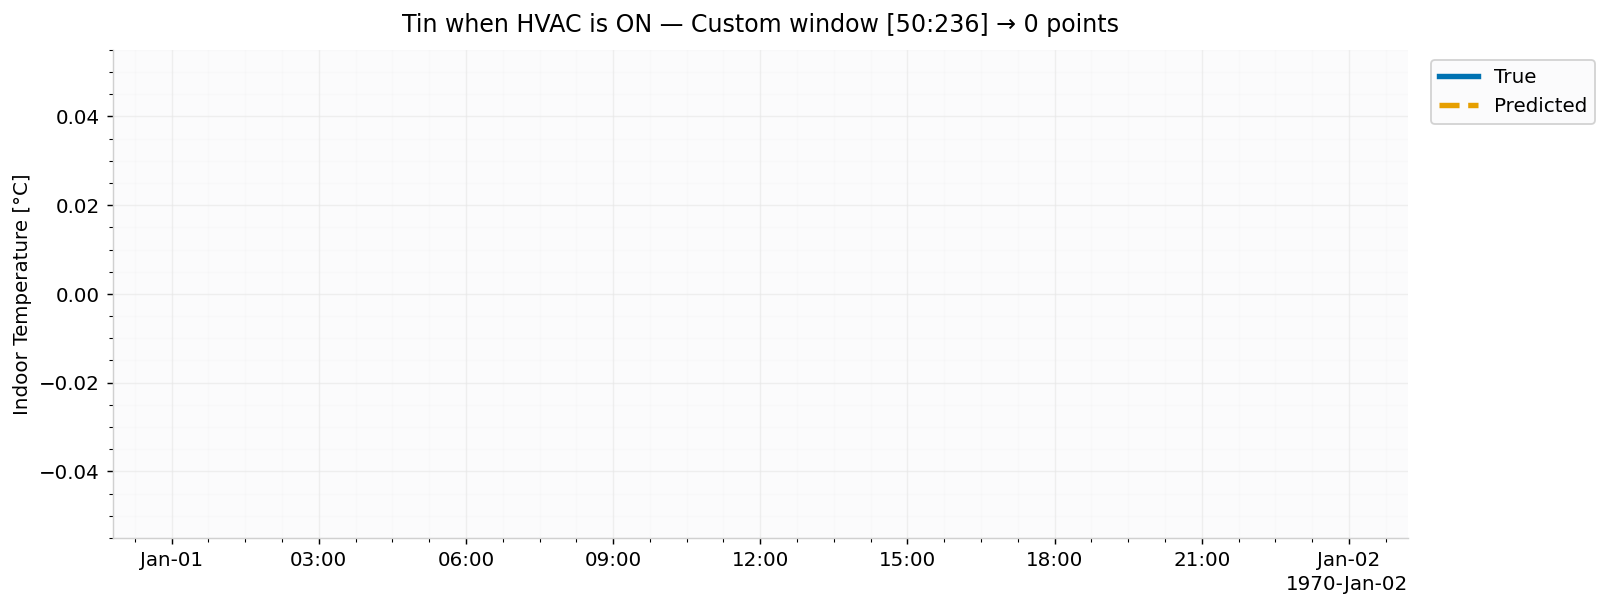

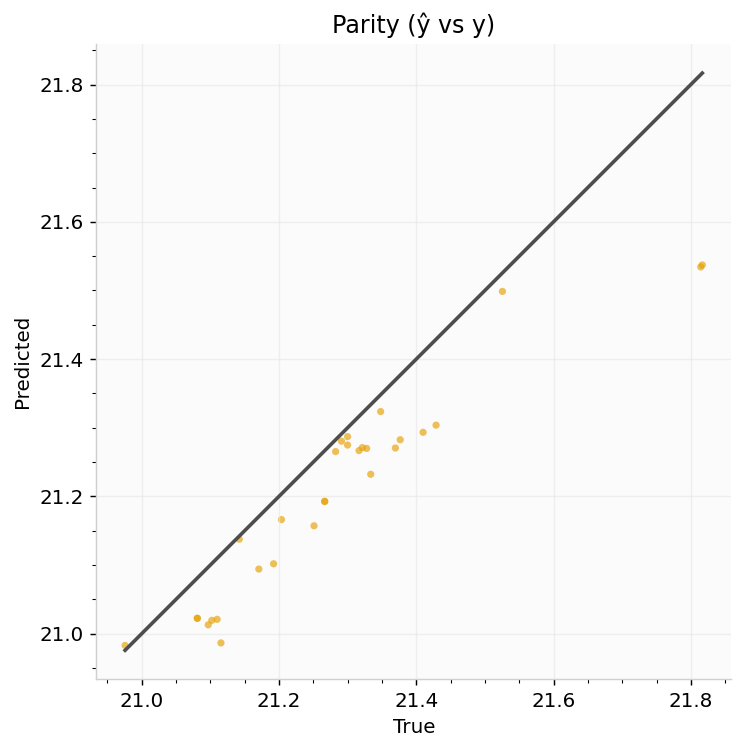

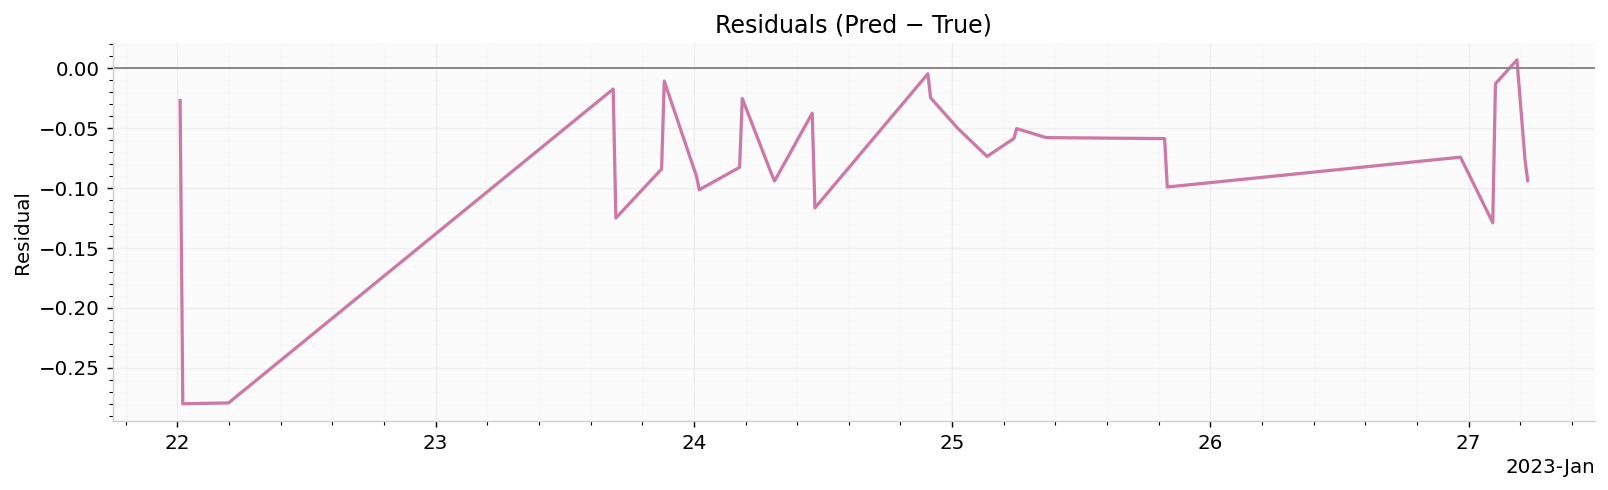

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 80}
Best CV MAE: 0.09559160248183345
Test MAE: 0.080 °C
Test MAPE: 0.397 %
[df_5] Saved best RF model → models/df_5\best_model_rf.pk1

               Performance Metrics             
   Metric  Value
     RMSE 0.1045
      MAE 0.0795
       R² 0.8699
sMAPE (%) 0.3959



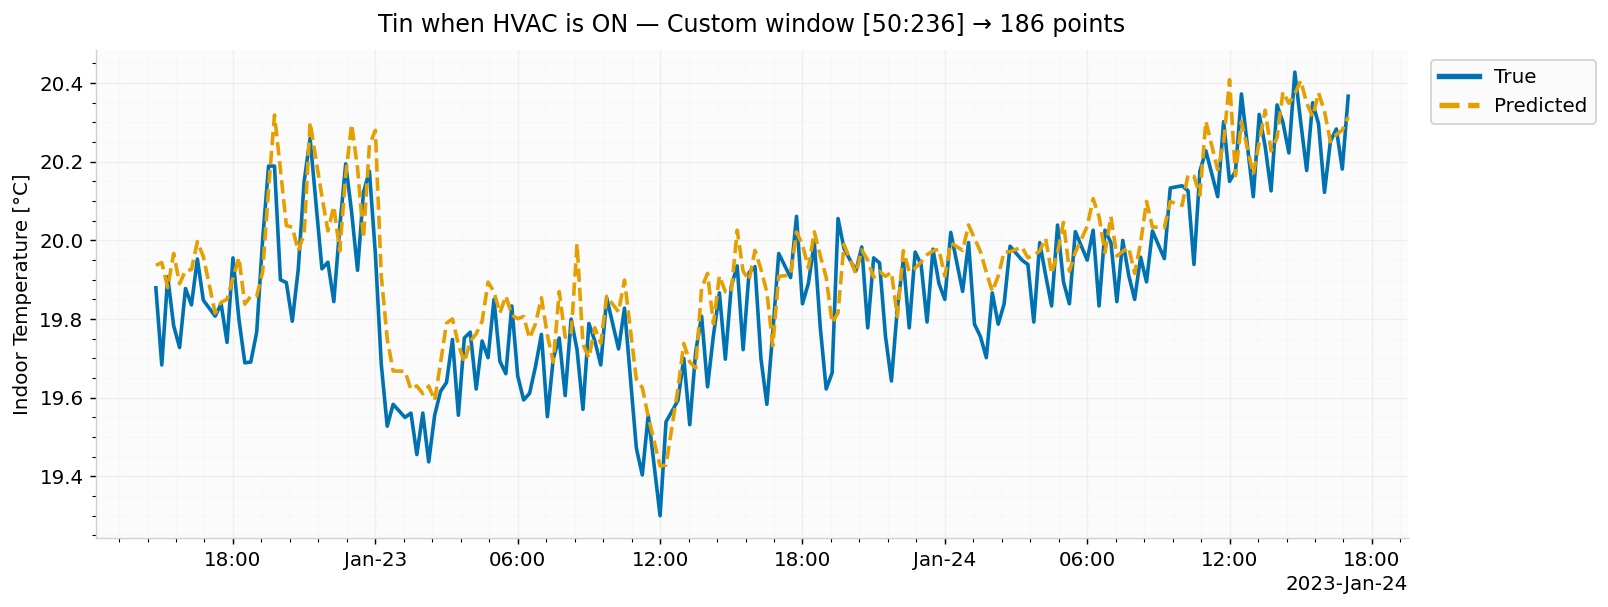

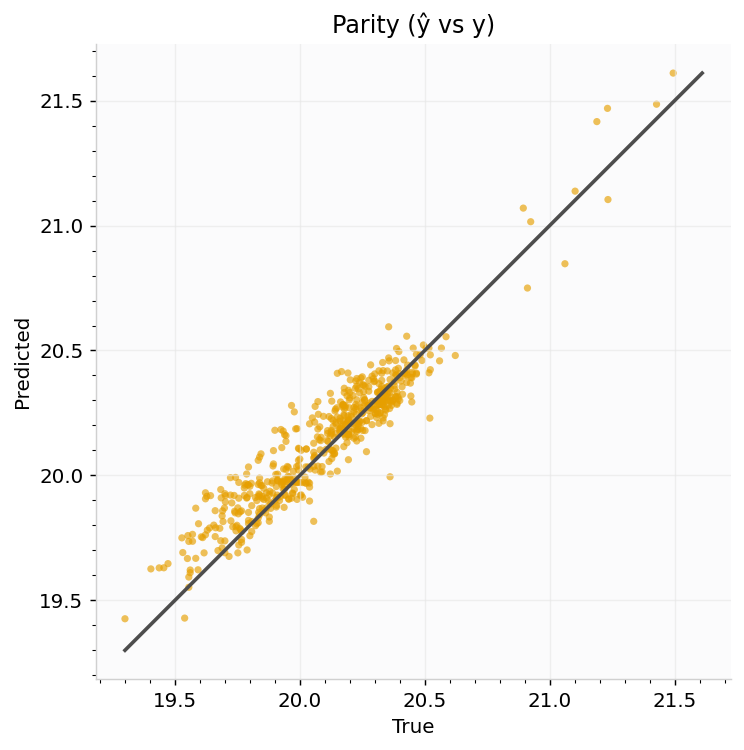

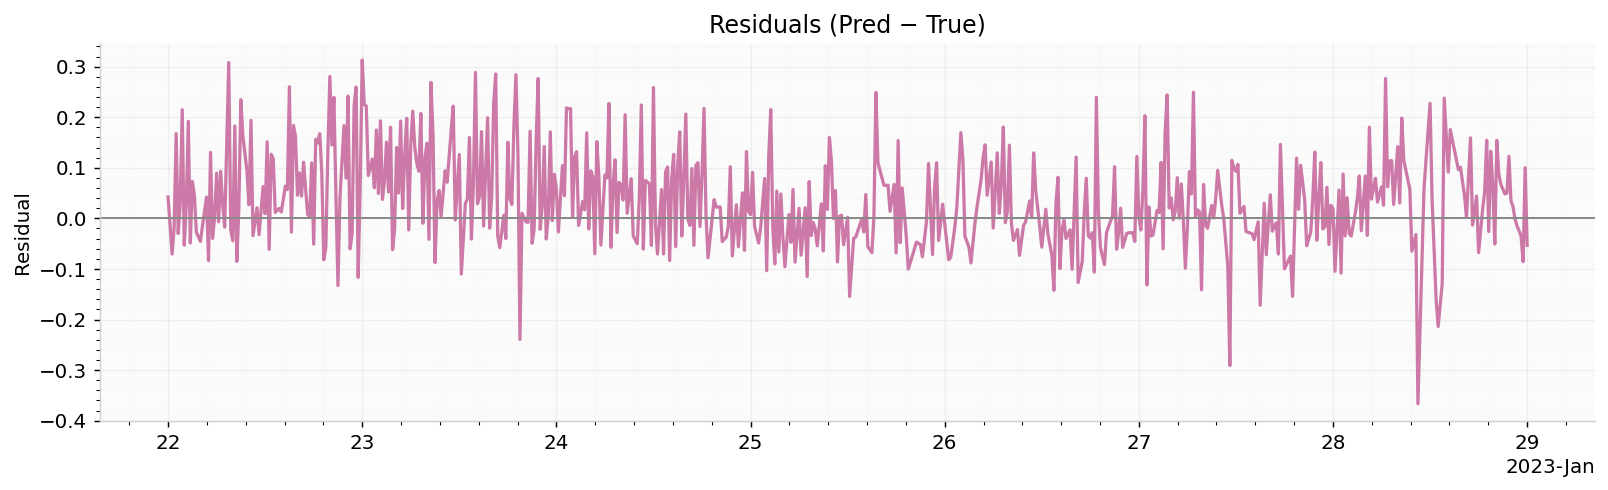

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 80}
Best CV MAE: 0.42308811939387025
Test MAE: 0.073 °C
Test MAPE: 0.369 %
[df_6] Saved best RF model → models/df_6\best_model_rf.pk1

               Performance Metrics             
   Metric  Value
     RMSE 0.0884
      MAE 0.0725
       R² 0.7484
sMAPE (%) 0.3686



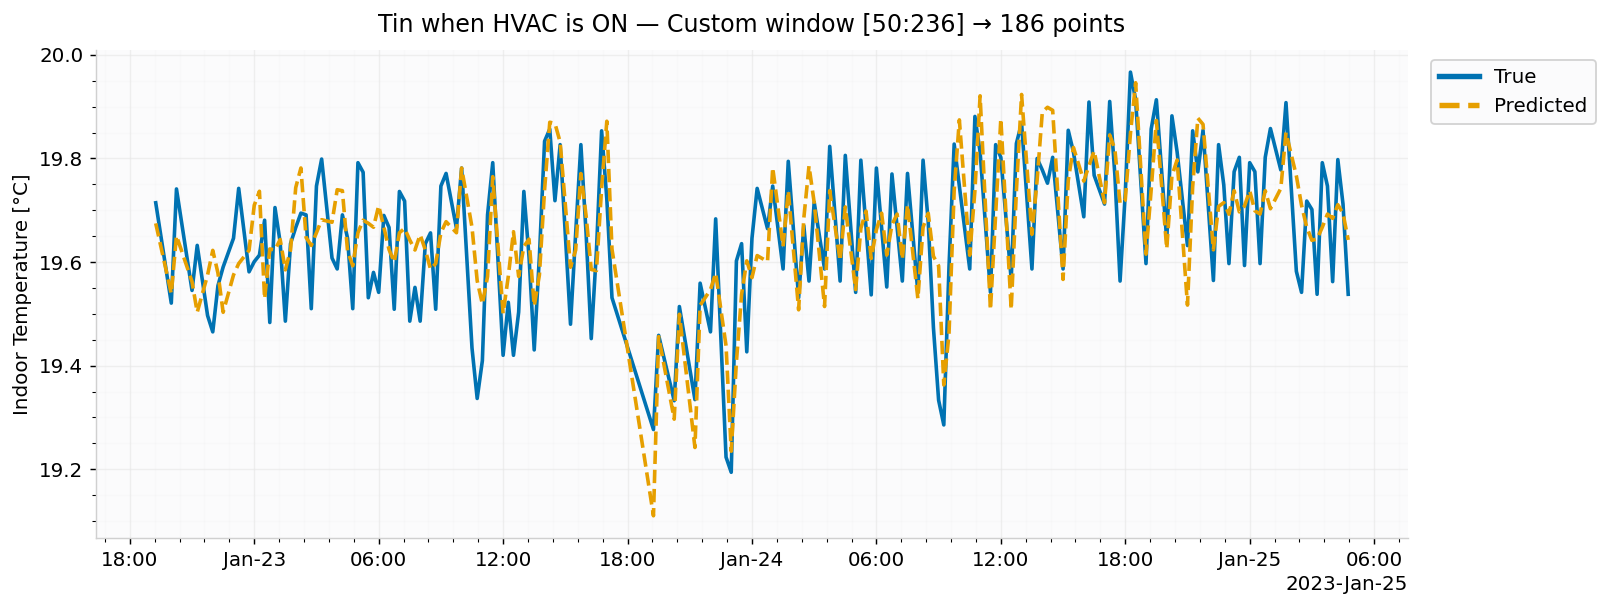

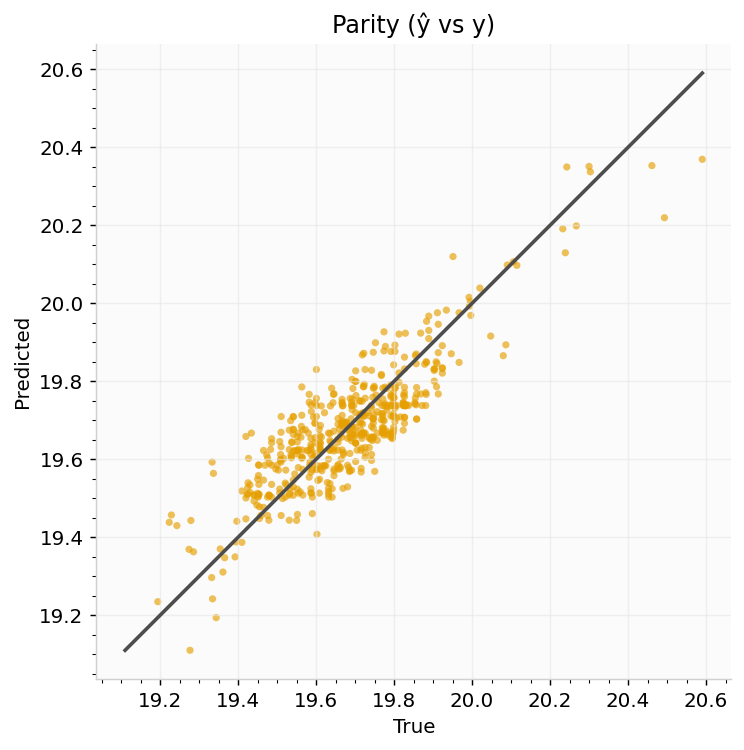

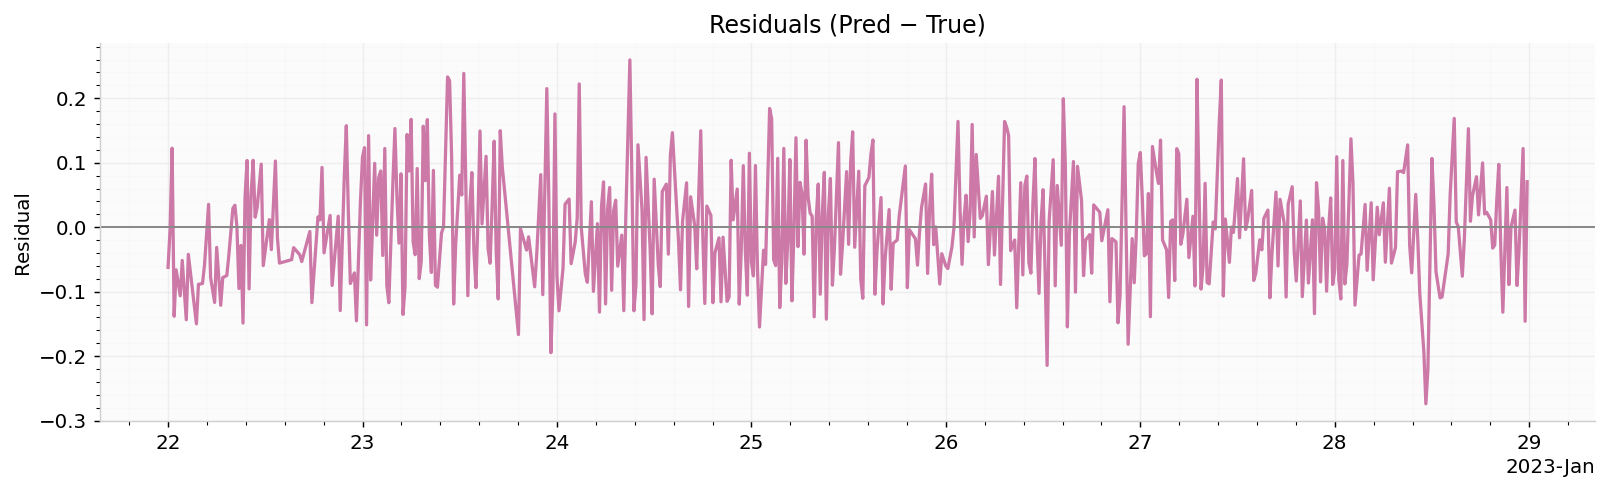

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Best Params: {'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 2, 'n_estimators': 160}
Best CV MAE: 0.1387584232421414
Test MAE: 0.106 °C
Test MAPE: 0.559 %
[df_7] Saved best RF model → models/df_7\best_model_rf.pk1

               Performance Metrics             
   Metric  Value
     RMSE 0.1334
      MAE 0.1061
       R² 0.8059
sMAPE (%) 0.5589



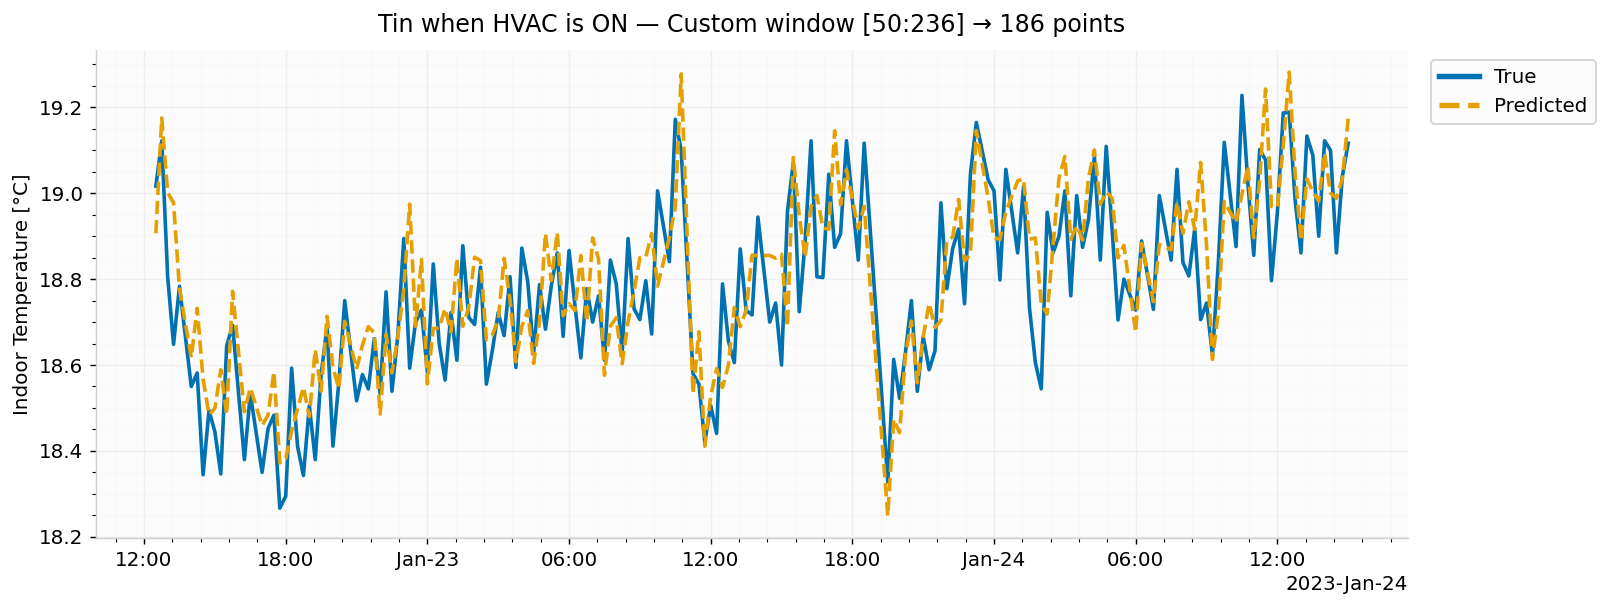

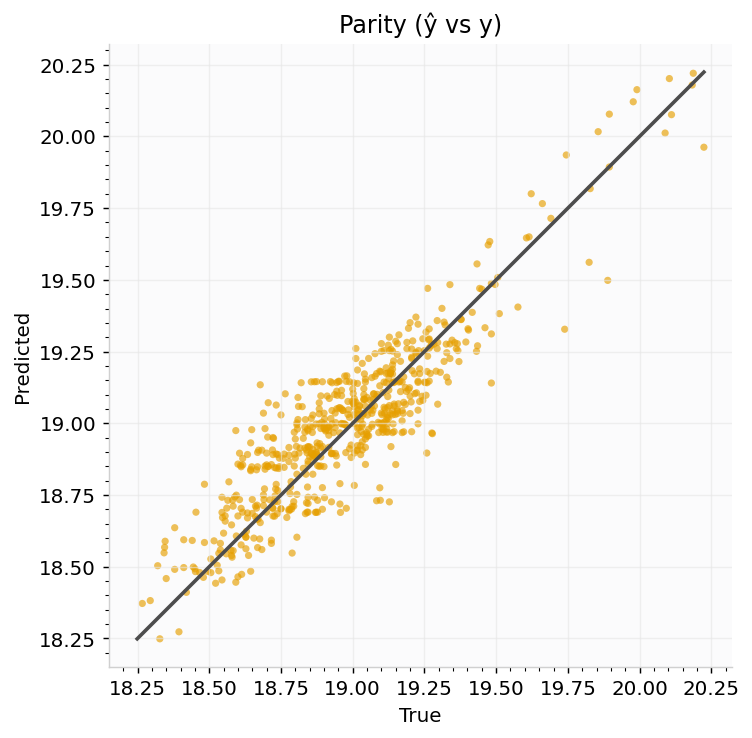

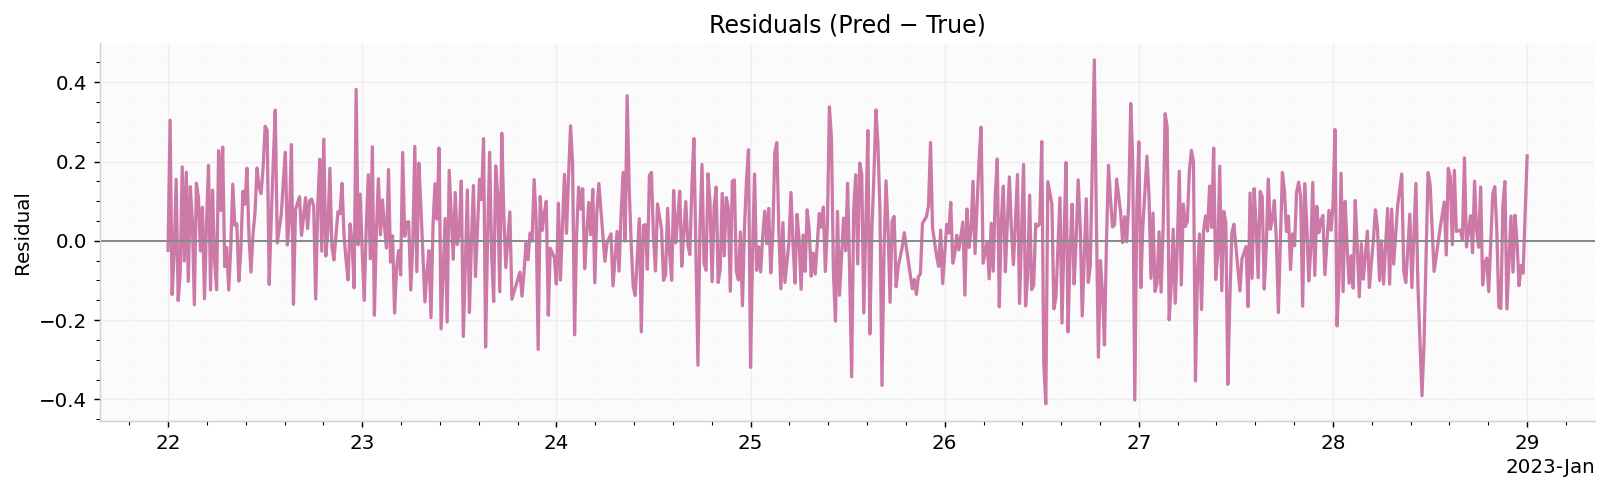

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from cycler import cycler
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean(2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100.0

COLORS = {
    "true":   "#0072B2",  # blue
    "pred":   "#E69F00",  # orange
    "resid":  "#CC79A7",  # magenta
    "eqline": "#4D4D4D",  # dark gray
    "zero":   "#8A8A8A",  # mid gray
}

def setup_matplotlib():
    plt.rcParams.update({
        "figure.dpi": 130,
        "figure.facecolor": "white",
        "axes.facecolor": "#FBFBFC",
        "axes.edgecolor": "#D0D0D0",
        "axes.linewidth": 0.8,
        "axes.grid": True,
        "grid.color": "#E6E6E6",
        "grid.alpha": 0.6,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "legend.frameon": True,
        "legend.framealpha": 0.95,
        "legend.edgecolor": "#D0D0D0",
        "font.size": 11,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "lines.linewidth": 2.2,     # a little bolder by default
        "axes.prop_cycle": cycler("color", [COLORS["true"], COLORS["pred"], COLORS["resid"]]),
})
    
def format_time_axis(ax):
    loc = AutoDateLocator()
    fmt = ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)

def print_metrics_table(metrics_dict):
    dfm = pd.DataFrame({
        "Metric": ["RMSE", "MAE", "R²", "sMAPE (%)"],
        "Value": [metrics_dict["rmse"], metrics_dict["mae"], metrics_dict["r2"], metrics_dict["smape"]]
    })
    dfm["Value"] = dfm["Value"].map(lambda v: f"{v:,.4f}")
    bar = "="*47
    print("\n" + bar)
    print(" Performance Metrics".center(47, " "))
    print(bar)
    print(dfm.to_string(index=False))
    print(bar + "\n")
    return dfm

def evaluate_and_plot(y_true, y_pred, times, outdir, ylabel="Temperature (°C)", prefix="rf", start_idx=None, end_idx=None, n_skip=6, n_plot=192):
    os.makedirs(outdir, exist_ok=True)
    setup_matplotlib()

    # --- metrics ---
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    smp  = smape(y_true, y_pred)
    metrics = {"rmse": rmse, "mae": mae, "r2": r2, "smape": smp}

    # print & save metrics
    metrics_df_print = print_metrics_table(metrics)
    metrics_df_save  = pd.DataFrame(metrics, index=[0])
    metrics_df_save.to_csv(os.path.join(outdir, f"{prefix}_metrics.csv"), index=False)

    # results frame
    results = pd.DataFrame({
        "y_true": np.asarray(y_true, dtype=float),
        "y_pred": np.asarray(y_pred, dtype=float)
    }, index=pd.to_datetime(times)).sort_index()
    residuals = results["y_pred"] - results["y_true"]

    # ------------- (1) time-series plot (zoom on a neat window) -------------
    if start_idx is not None and end_idx is not None:
        seg = results.iloc[start_idx:end_idx]
        window_note = f"Custom window [{start_idx}:{end_idx}] → {len(seg)} points"
    else:
        N_plot = min(n_plot, max(0, len(results) - n_skip)) if len(results) > n_skip else len(results)
        seg = results.iloc[n_skip:n_skip + N_plot] if N_plot > 0 else results
        window_note = f"{len(seg)} points (skip {n_skip})"

    fig, ax = plt.subplots(figsize=(12.5, 4.8))
    ax.plot(seg.index, seg["y_true"], linewidth=2.0, label="True", color=COLORS["true"])
    ax.plot(seg.index, seg["y_pred"], linewidth=2.0, linestyle="--", label="Predicted", color=COLORS["pred"])
    ax.set_title(f"Tin when HVAC is ON — {window_note}", pad=10)

    ax.set_ylabel(ylabel)
    format_time_axis(ax)
    leg = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))
    for line in leg.get_lines():
        line.set_linewidth(3)
    fig.tight_layout()
    # fig.savefig(os.path.join(outdir, f"{prefix}_timeseries.png"), bbox_inches="tight")
    plt.show()

    # ------------- (2) parity plot -------------
    fig, ax = plt.subplots(figsize=(5.9, 5.9))
    ax.scatter(results["y_true"], results["y_pred"], s=16, alpha=0.65, edgecolors="none", color=COLORS["pred"])
    mn = float(np.nanmin([results["y_true"].min(), results["y_pred"].min()]))
    mx = float(np.nanmax([results["y_true"].max(), results["y_pred"].max()]))
    ax.plot([mn, mx], [mn, mx], linewidth=2.0, color=COLORS["eqline"])
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title("Parity (ŷ vs y)")
    ax.minorticks_on()
    fig.tight_layout()
    plt.show()

    # ------------- (3) residuals over time -------------
    fig, ax = plt.subplots(figsize=(12.5, 3.9))
    ax.plot(results.index, residuals, linewidth=1.8, color=COLORS["resid"])
    ax.axhline(0.0, linewidth=1.1, color=COLORS["zero"])
    ax.set_title("Residuals (Pred − True)")
    ax.set_ylabel("Residual")
    format_time_axis(ax)
    fig.tight_layout()
    plt.show()

    return metrics


feature_cols = [
    'Tin',        
    'hvac_mode',
    'Tout',
    'T_diff',
]

for index, df in enumerate(dfs):
    df['T_diff'] = (df['Tout'] - df['Tin']).bfill()

    df['Tin_target']  = df['Tin'].shift(-1).dropna()          
    # df['is_test'] = (df.index >= test_start) & (df.index <= test_end)

    df_on = df[df['pump_energy'] > 0].copy()

    df_on_train = df_on[~df_on['is_test']]
    df_on_test = df_on[df_on['is_test']]

    target_col = 'Tin_target'  

    X_train = df_on_train[feature_cols]
    X_test = df_on_test[feature_cols]
    y_train = df_on_train[target_col]
    y_test = df_on_test[target_col]

    mask = ~y_train.isna()
    X_train = X_train[mask]
    y_train = y_train[mask]

    param_grid = {
        'n_estimators': [60, 80, 100, 120, 160, 200],
        'max_depth': [6, 8, 10, 12, 14],
        'min_samples_leaf': [1, 3, 5, 7, 9],
        'min_samples_split': [2, 5, 10]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    rf = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        rf,
        param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error', 
        verbose=2,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)
    print("Best Params:", grid.best_params_)
    print("Best CV MAE:", -grid.best_score_)

    y_true = y_test.values

    y_pred = grid.best_estimator_.predict(X_test)
    mae = np.mean(np.abs(y_pred - y_test))
    mape = np.mean(np.abs((y_pred - y_test) / y_test)) * 100
    print(f"Test MAE: {mae:.3f} °C")
    print(f"Test MAPE: {mape:.3f} %")

    best_model_rf = grid.best_estimator_
    
    save_dir = f"models/df_{index}"
    os.makedirs(save_dir, exist_ok=True)
    rf_path = os.path.join(save_dir, 'best_model_rf.pk1')
    joblib.dump(best_model_rf, rf_path)
    start_idx = 50
    end_idx = start_idx + 186 #2 days
    y_true = y_test.values

    y_plot = y_true[start_idx:end_idx]
    y_pred_xg_plot = y_pred[start_idx:end_idx]

    print(f"[df_{index}] Saved best RF model → {rf_path}")

    # evaluate + plots
    ylabel = "Indoor Temperature [°C]"
    metrics = evaluate_and_plot(
        y_true=y_test.values,
        y_pred=y_pred,
        times=y_test.index,          # keep temporal x-axis
        outdir=save_dir,
        ylabel=ylabel,
        prefix="rf_on",
        start_idx=start_idx,
        end_idx=end_idx,
    )


In [42]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from cycler import cycler
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
from typing import Tuple
import torch.nn as nn
import torch

COLORS = {
    "true":   "#0072B2",  # blue
    "pred":   "#E69F00",  # orange
    "hvac":   "#009E73",  # green
    "comfort_true": "#56B4E9",  # light blue
    "comfort_pred": "#D55E00",  # vermillion
    "zero":   "#8A8A8A",
}
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#FBFBFC",
    "axes.edgecolor": "#D0D0D0",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#E6E6E6",
    "grid.alpha": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "#D0D0D0",
    "font.size": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "lines.linewidth": 2.2,
    "axes.prop_cycle": cycler("color", [COLORS["true"], COLORS["pred"]]),
})

class TCNRegressor(nn.Module):
    def __init__(self, in_dim, out_dim=1, hidden=128, kernel_size=3, dropout=0.15, levels=4):
        super().__init__()
        layers = []
        dilation = 1
        for _ in range(levels):
            layers += [
                nn.Conv1d(in_dim, hidden, kernel_size, padding=(kernel_size-1)*dilation, dilation=dilation),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            in_dim = hidden
            dilation *= 2
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(hidden, out_dim)

    def forward(self, x):
        # x shape: (batch, seq_len, features) → (batch, features, seq_len)
        x = x.transpose(1, 2)
        x = self.network(x)
        out = x[:, :, -1]  # last time step
        return self.fc(out).squeeze(-1)

def _format_time_axis(ax):
    loc = AutoDateLocator()
    fmt = ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)

def load_scaler_or_fallback(i, name):
    p1 = f"models/scalers/df_{i}/{name}.pkl"
    p2 = f"models/df_{i}/{name}.pkl"
    if os.path.exists(p1): return joblib.load(p1)
    if os.path.exists(p2): return joblib.load(p2)
    raise FileNotFoundError(f"Scaler {name} not found for df_{i} in {p1} or {p2}")

def load_models_for_house(i):
    models_dir = f"models/df_{i}"

    tcn_model = TCNRegressor(in_dim=9)  # 7 = Tin, Tout, T_diff, hour_sin, hour_cos, dow_sin, dow_cos
    tcn_model.load_state_dict(torch.load(os.path.join(models_dir, "best_tinv2.pt"), map_location="cpu"))
    tcn_model.eval()
    # model_tin = LSTMWithFuture(input_size=3, hidden_size=128, num_layers=2)
    # model_tin.load_state_dict(torch.load(os.path.join(models_dir, "best_tin.pt"), map_location="cpu"))
    # model_tin.eval()
   
    model_rh = CNNLSTMWithFuture(input_size=7, hidden_size=128, num_layers=2,  cnn_out_channels=32, kernel_size=3)
    model_rh.load_state_dict(torch.load(os.path.join(models_dir, "best_rh.pt"), map_location="cpu"))
    model_rh.eval()

    rf_model = joblib.load(os.path.join(models_dir, "best_model_rf.pkl"))

    # Scalers
    scaler_tin = load_scaler_or_fallback(i, "scaler_tin")
    scaler_rh  = load_scaler_or_fallback(i, "scaler_rh")

    return tcn_model, model_rh, rf_model, scaler_tin, scaler_rh

def plot_48h(results_48h, df_ref, house_tag=""):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13.0, 8.2), sharex=True)

    # Top: Tin + HVAC
    ax1.plot(results_48h.index, results_48h['Tin_true'], label='Tin True', color=COLORS['true'])
    ax1.plot(results_48h.index, results_48h['Tin_pred'], label='Tin Pred', color=COLORS['pred'], linestyle='--')
    ax1.set_ylabel('Indoor Temperature [°C]')
    ax1b = ax1.twinx()
    ax1b.step(results_48h.index, results_48h['hvac_mode'], where='post',
              label='HVAC mode', color=COLORS['hvac'], linewidth=1.8, alpha=0.9)
    ax1b.set_ylabel('HVAC (0/1/2)'); ax1b.set_yticks([0,1,2])
    ax1.legend(loc="upper left"); ax1b.legend(loc="upper right")
    _format_time_axis(ax1)
    ax1.set_title(f"df {house_tag} • Tin (True vs Pred) + HVAC activations", pad=10)

    # Bottom: RH + Comfort
    ax2.plot(results_48h.index, results_48h['RH_true'],  label='RH True', color=COLORS['true'])
    ax2.plot(results_48h.index, results_48h['RH_pred'],  label='RH Pred', color=COLORS['pred'], linestyle='--')
    ax2.set_ylabel('Relative Humidity [%]')

    plt.tight_layout()
    plt.show()

def predict_Tin_sequence_full(
    df_test,               
    window_start_idx,      
    tcn_model,               
    rf_model,   
    tin_scaler,
    rh_model,
    rh_scaler,
    window_size=24,
    window_size_rh=24,       
    n_steps=96,
):
    
    tcn_model.eval()
    rh_model.eval()

    results = []

    tin_input_seq = []
    rh_input_seq = []

    for i in range(window_size):
        row_tin = df_test.iloc[window_start_idx - window_size + i]
        tin_input_row = [
        row_tin['Tin'],
        row_tin['Tout'],
        row_tin['Tout_diff'],
        row_tin['hour_sin'],
        row_tin['hour_cos'],
        row_tin['dow_sin'],
        row_tin['dow_cos'],
        row_tin['Tout_lag1'],
        row_tin['Tout_fut1']
        ]

        tin_scaled = tin_scaler.transform([tin_input_row])[0]
        tin_scaled_final = list(tin_scaled)
        tin_input_seq.append(tin_scaled_final)

    for i in range(window_size_rh):
        row_rh = df_test.iloc[window_start_idx - window_size_rh + i]
        rh_raw_features = [
            row_rh['Tout']
        ]
        hvac_0 = row_rh['hvac_0']
        hvac_1 = row_rh['hvac_1']
        hvac_2 = row_rh['hvac_2']
        rh_scaled = rh_scaler.transform([rh_raw_features])[0]
        rh_input_row = [row_rh['RH']] + list(rh_scaled) + [hvac_0, hvac_1, hvac_2] + [row_rh['hour_sin'], row_rh['hour_cos']]
        rh_input_seq.append(rh_input_row)
 
    start_row = df_test.iloc[window_start_idx]
    pred_tin_buffer = [
        start_row['Tin']
    ]

    pred_rh_buffer = [
        start_row['RH']
    ]

    results = []

    for step in range(n_steps):
        idx = window_start_idx + step
        row = df_test.iloc[idx]
        Tout = row['Tout']
        hvac_mode = row['hvac_mode']
        hvac_0 = row['hvac_0']
        hvac_1 = row['hvac_1'] 
        hvac_2 = row['hvac_2']
        T_diff = row['Tout'] - pred_tin_buffer[0]


        if hvac_mode == 0:

            tin_input = [
                pred_tin_buffer[0],       
                Tout, 
                row['Tout_diff'],         
                row['hour_sin'],
                row['hour_cos'],
                row['dow_sin'],
                row['dow_cos'],
                row['Tout_lag1'],
                row['Tout_fut1']   
            ]

            scaled_input_tin = tin_scaler.transform([tin_input])[0]
            tin_input_seq = tin_input_seq[1:] + [list(scaled_input_tin)]
      
            x_seq = torch.tensor([tin_input_seq], dtype=torch.float32)

           
            with torch.no_grad():
                Tin_pred = tcn_model(x_seq).item()

         
        else:
            rf_input = pred_tin_buffer + [hvac_mode] + [Tout] + [T_diff]
            Tin_pred = rf_model.predict([rf_input])[0]
        
    
     
        pred_tin_buffer = [Tin_pred] 

        rh_raw_features =  [Tout]
        scaled_rh_features = rh_scaler.transform([rh_raw_features])[0]
        rh_input_row = [pred_rh_buffer[0]] + list(scaled_rh_features) + [hvac_0, hvac_1, hvac_2, row['hour_sin'], row['hour_cos']]
        rh_input_seq = rh_input_seq[1:] + [rh_input_row]
        print(f"[{step:02d}] RH_input: RH_prev={pred_rh_buffer[0]:.2f} | Tout={Tout:.2f} (scaled={scaled_rh_features[0]:.3f}) | HVAC={hvac_mode} | RH_true={row['RH']:.2f}")

        rh_seq_tensor = torch.tensor([rh_input_seq], dtype=torch.float32)
      
        with torch.no_grad():
            RH_pred = rh_model(rh_seq_tensor).item()

        pred_rh_buffer = [RH_pred]

        results.append({
            'timestamp': df_test.index[idx],
            'Tin_pred': Tin_pred,
            'Tin_true': row['Tin'],
            'hvac_mode': hvac_mode,
            'Tin_target': row['Tin_target'],
            'RH_pred': RH_pred,
            'RH_true': row['RH'],
        })

        # lag_buffer = [Tin_pred] + lag_buffer[:-1]

    return pd.DataFrame(results).set_index('timestamp')

def make_splits_by_is_test_or_date(
    df: pd.DataFrame,
    val_start_str: str = "2023-01-22",
    val_days: int = 14,
    test_days: int = 14,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
   
    # Ensure datetime index
    if not isinstance(df.index, pd.DatetimeIndex):
        if "timestamps" in df.columns:
            df = df.copy()
            df["timestamps"] = pd.to_datetime(df["timestamps"])
            df = df.set_index("timestamps")
        else:
            raise ValueError("DataFrame must have a DateTimeIndex or a 'timestamps' column.")

    # Define windows
    val_start = pd.Timestamp(val_start_str)
    val_end   = val_start + pd.Timedelta(days=val_days)
    test_start = val_end
    test_end   = test_start + pd.Timedelta(days=test_days)

    # Build masks (inclusive start, exclusive end)
    idx = np.arange(len(df))
    ts = df.index

    val_mask  = (ts >= val_start) & (ts < val_end)
    test_mask = (ts >= test_start) & (ts < test_end)

    # Ensure they are disjoint
    overlap = val_mask & test_mask
    if overlap.any():
        raise RuntimeError("Validation and test windows overlap; check the inputs.")

    train_mask = ~(val_mask | test_mask)

    train_idx = idx[train_mask]
    val_idx   = idx[val_mask]
    test_idx  = idx[test_mask]

    return train_idx, val_idx, test_idx



=== Running df_0 ===
[00] RH_input: RH_prev=26.00 | Tout=4.01 (scaled=-0.437) | HVAC=0 | RH_true=26.00
[01] RH_input: RH_prev=26.17 | Tout=3.92 (scaled=-0.447) | HVAC=1 | RH_true=26.03
[02] RH_input: RH_prev=26.18 | Tout=3.89 (scaled=-0.450) | HVAC=2 | RH_true=26.45
[03] RH_input: RH_prev=26.46 | Tout=4.00 (scaled=-0.437) | HVAC=0 | RH_true=26.50
[04] RH_input: RH_prev=26.69 | Tout=3.79 (scaled=-0.461) | HVAC=0 | RH_true=26.50
[05] RH_input: RH_prev=26.92 | Tout=3.32 (scaled=-0.512) | HVAC=0 | RH_true=26.82
[06] RH_input: RH_prev=27.25 | Tout=2.79 (scaled=-0.571) | HVAC=2 | RH_true=27.00
[07] RH_input: RH_prev=27.56 | Tout=2.70 (scaled=-0.581) | HVAC=1 | RH_true=27.03
[08] RH_input: RH_prev=28.05 | Tout=2.80 (scaled=-0.569) | HVAC=0 | RH_true=27.45
[09] RH_input: RH_prev=28.70 | Tout=2.74 (scaled=-0.575) | HVAC=0 | RH_true=27.85
[10] RH_input: RH_prev=29.16 | Tout=2.55 (scaled=-0.596) | HVAC=2 | RH_true=28.45
[11] RH_input: RH_prev=29.63 | Tout=2.40 (scaled=-0.613) | HVAC=0 | RH_true=

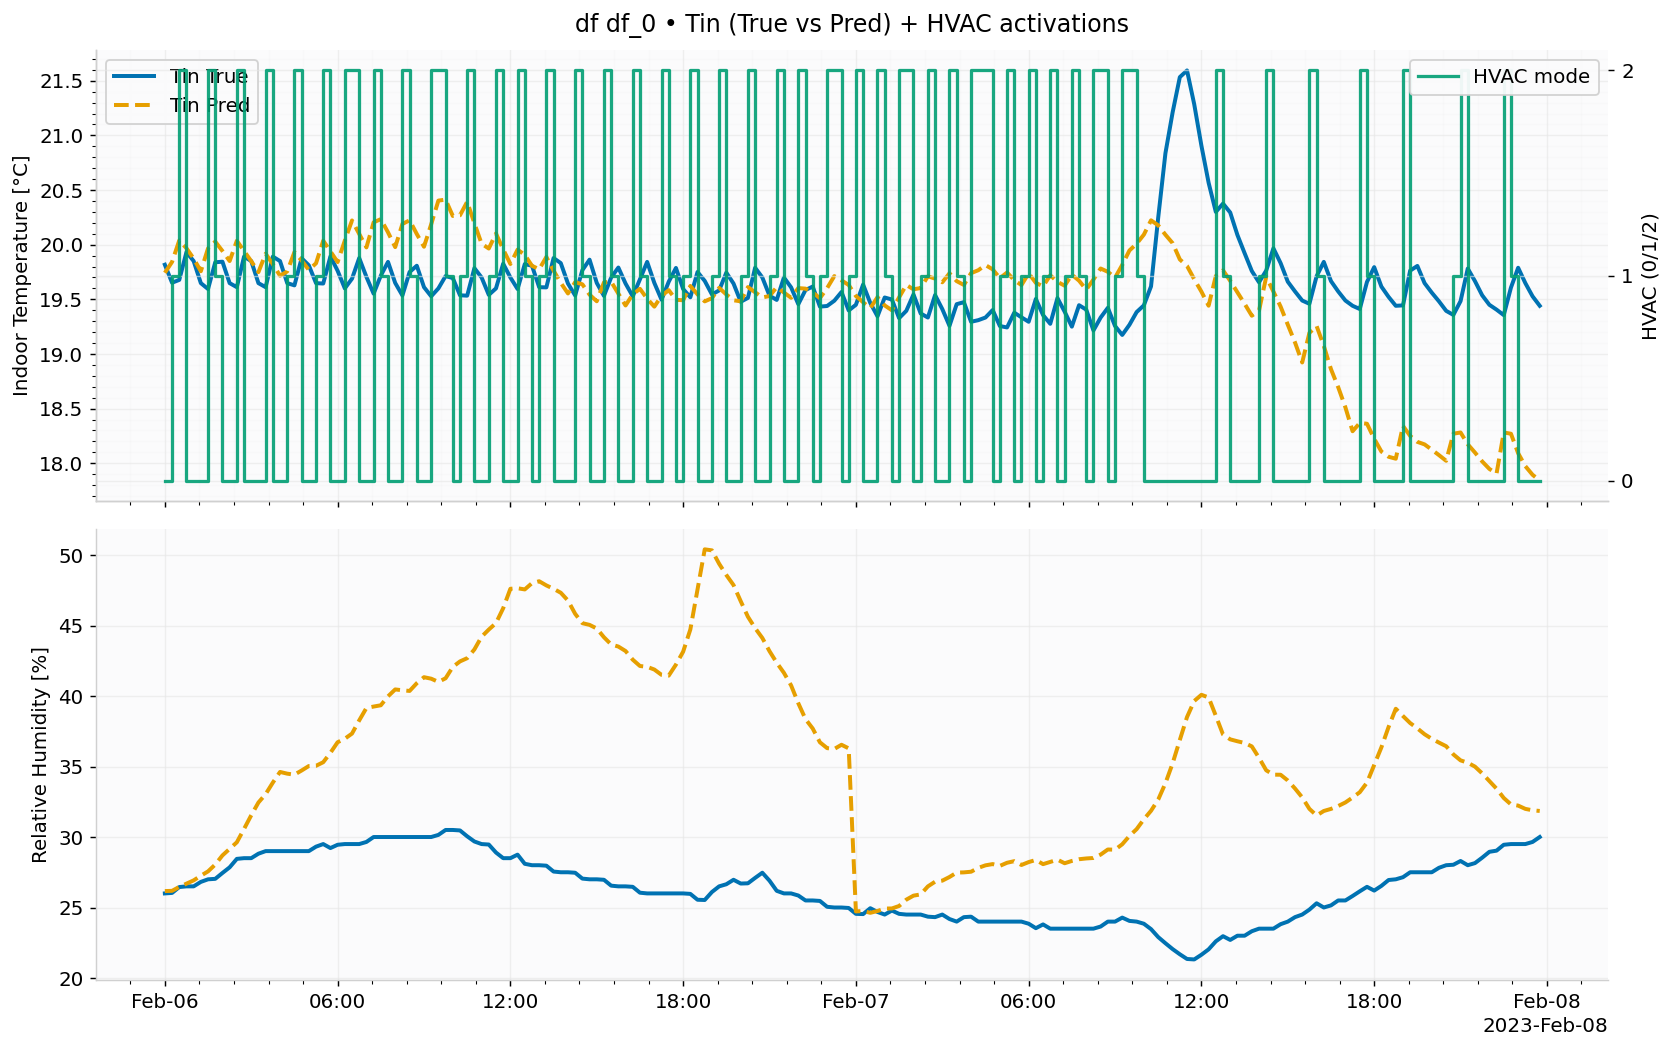


=== Running df_1 ===
[00] RH_input: RH_prev=30.85 | Tout=4.01 (scaled=-0.437) | HVAC=0 | RH_true=30.85
[01] RH_input: RH_prev=30.96 | Tout=3.92 (scaled=-0.447) | HVAC=0 | RH_true=30.50
[02] RH_input: RH_prev=31.05 | Tout=3.89 (scaled=-0.450) | HVAC=1 | RH_true=30.50
[03] RH_input: RH_prev=30.84 | Tout=4.00 (scaled=-0.437) | HVAC=1 | RH_true=30.15
[04] RH_input: RH_prev=30.83 | Tout=3.79 (scaled=-0.461) | HVAC=1 | RH_true=29.55
[05] RH_input: RH_prev=31.21 | Tout=3.32 (scaled=-0.512) | HVAC=1 | RH_true=29.50
[06] RH_input: RH_prev=31.81 | Tout=2.79 (scaled=-0.571) | HVAC=1 | RH_true=29.50
[07] RH_input: RH_prev=32.54 | Tout=2.70 (scaled=-0.581) | HVAC=1 | RH_true=29.50
[08] RH_input: RH_prev=33.29 | Tout=2.80 (scaled=-0.569) | HVAC=1 | RH_true=29.50
[09] RH_input: RH_prev=33.92 | Tout=2.74 (scaled=-0.575) | HVAC=1 | RH_true=29.50
[10] RH_input: RH_prev=34.42 | Tout=2.55 (scaled=-0.596) | HVAC=2 | RH_true=29.50
[11] RH_input: RH_prev=34.59 | Tout=2.40 (scaled=-0.613) | HVAC=1 | RH_true=

KeyboardInterrupt: 

In [43]:
# df_test = df[df['is_test']].copy()
# df_encoded_test = df_test.copy()
# df_encoded_test = df_encoded_test.join(pd.get_dummies(df_test['hvac_mode'], prefix='hvac'))


for i, df in enumerate(dfs):
    df_encoded = df.copy()
    df_encoded = df_encoded.join(pd.get_dummies(df['hvac_mode'], prefix='hvac'))
    train_idx, val_idx, test_idx = make_splits_by_is_test_or_date(df_encoded)

    df_encoded_test = df_encoded.iloc[test_idx].copy()

    START_1 = 96
    STEPS = 96  # 24h

    print(f"\n=== Running df_{i} ===")
    # 1) Models & scalers
    model_tin, model_rh, rf_model, scaler_tin, scaler_rh = load_models_for_house(i)

    # 3) First day (start 26)
    res_day1 = predict_Tin_sequence_full(
        df_test=df_encoded_test,
        window_start_idx=START_1,
        tcn_model=model_tin,
        rf_model=rf_model,
        tin_scaler=scaler_tin,
        rh_model=model_rh,
        rh_scaler=scaler_rh,
        window_size=24,
        window_size_rh=24,
        n_steps=STEPS,
    )

    # 4) Second day (start 26 + 96)
    res_day2 = predict_Tin_sequence_full(
        df_test=df_encoded_test,
        window_start_idx=START_1 + STEPS,
        tcn_model=model_tin,
        rf_model=rf_model,
        tin_scaler=scaler_tin,
        rh_model=model_rh,
        rh_scaler=scaler_rh,
        window_size=24,
        window_size_rh=24,
        n_steps=STEPS,
    )

    # 5) Combine 48h & plot
    results_48h = pd.concat([res_day1, res_day2]).sort_index()
    plot_48h(results_48h, df_ref=df_encoded_test, house_tag=f"df_{i}")


# results_24h = predict_Tin_sequence_full(
#     df_test=df_encoded_test,
#     window_start_idx=26,
#     lstm_model=model_tin,
#     rf_model=grid.best_estimator_,
#     tin_scaler=scaler_tin,        
#     rh_model=model_rh,        
#     rh_scaler=scaler_rh,     
#     window_size=6,
#     window_size_rh=24,       
#     n_steps=96,
# )

# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)


# ax1.plot(results_24h.index, results_24h['Tin_true'], label='True Tin', marker='o', color='tab:blue')
# ax1.plot(results_24h.index, results_24h['Tin_pred'], label='Predicted Tin', marker='x', color='tab:orange')
# ax1.set_ylabel('Indoor Temperature [°C]')
# ax1.legend(loc='upper right')
# ax1.grid(True)

# ax1b = ax1.twinx()
# ax1b.plot(results_24h.index, results_24h['hvac_mode'], label='HVAC Mode', color='tab:green', linewidth=1.5, alpha=0.5)
# ax1b.set_ylabel('HVAC Mode (0=off, 1=low, 2=high)')
# ax1b.set_yticks([0, 1, 2])
# ax1b.legend(loc='upper right')

# ax2.plot(results_24h.index, results_24h['RH_true'], label='True RH', marker='o', color='tab:purple')
# ax2.plot(results_24h.index, results_24h['RH_pred'], label='Predicted RH', marker='x', color='tab:pink')
# ax2.set_xlabel('Time')
# ax2.set_ylabel('Relative Humidity [%]')
# ax2.legend(loc='upper left')
# ax2.grid(True)

# plt.suptitle('24h Indoor Temperature and Humidity Prediction with HVAC Overlay')
# plt.tight_layout()
# plt.show()

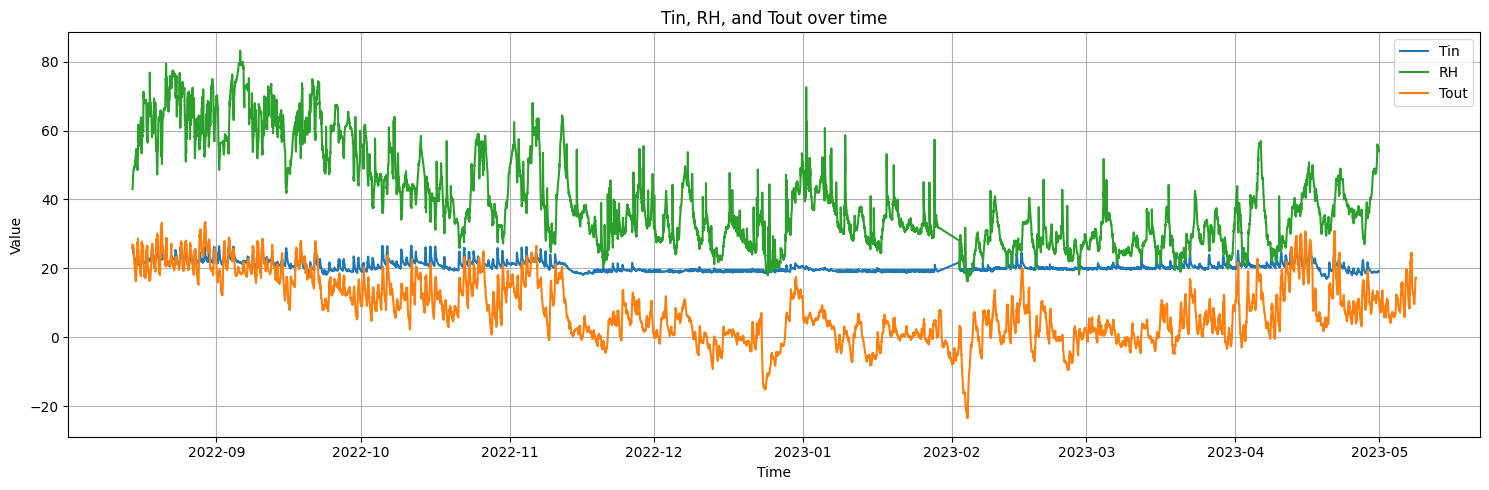

In [115]:

fig, ax1 = plt.subplots(figsize=(15, 5))

# Plot Tin
ax1.plot(df.index, df['Tin'], label='Tin', color='tab:blue')
ax1.plot(df.index, df['RH'], label='RH', color='tab:green')
ax1.plot(df.index, df['Tout'], label='Tout', color='tab:orange')

# # Mark test set boundary (optional)
# if 'df_test' in locals():
#     test_start = df_test.index[0]
#     test_end = df_test.index[-1]
#     ax1.axvspan(test_start, test_end, color='gray', alpha=0.2, label='Test period')

ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.set_title('Tin, RH, and Tout over time')
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()